# Cetelem — EDA
## Business Context

In [1]:
import importlib
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is on path
sys.path.insert(0, os.path.abspath(".."))

import src.code.eda_functions as f
import src.code.io_utils as io
import src.code.data_preparation as dp

importlib.reload(dp)
importlib.reload(f)
importlib.reload(io)

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)

print("Setup complete.")

Setup complete.


In [2]:
df = io.load("../data/prepared/EDA.parquet")

[LOAD] ../data/prepared/EDA.parquet | shape: (147415, 85)


# Univariative analysis

In [ ]:
dp.visualize_by_variable(df, dataset_name="BDOSS Dataset")


KeyboardInterrupt: 

# PART 1 — Understanding Early Settlement (IS_EARLY_SETTLER)

## 1.1 Target Definition & Distribution

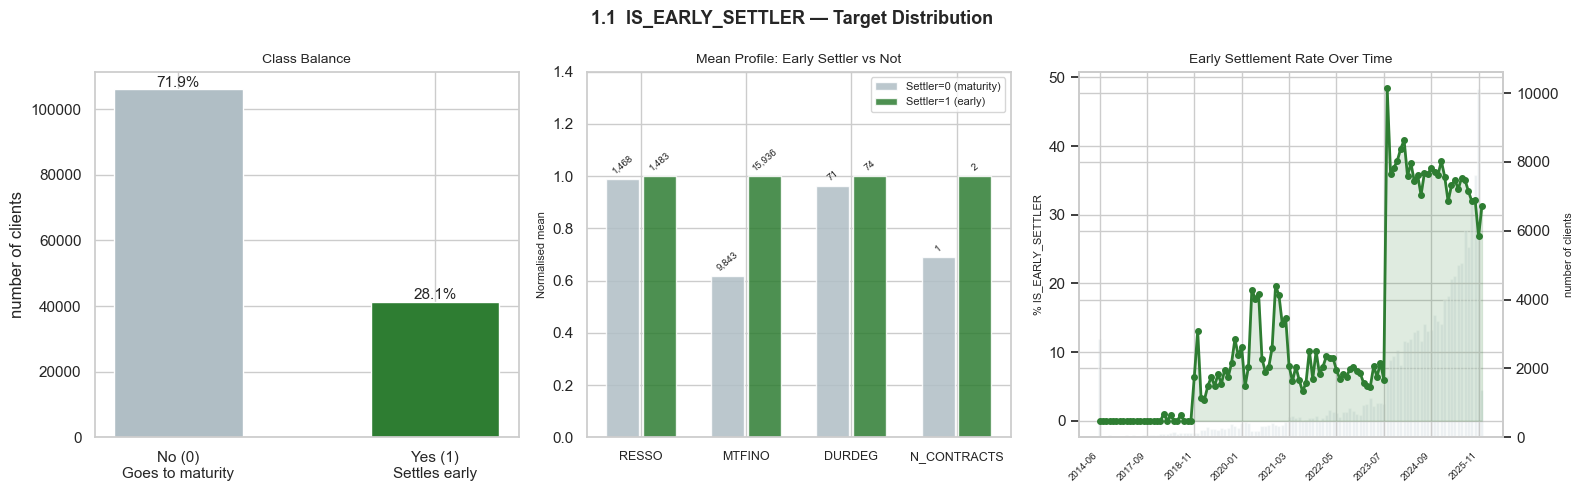

In [3]:
f.san_1_distribution(df)

### Class Balance
The dataset is imbalanced: **71.9% of clients complete their contract 
at maturity** (IS_EARLY_SETTLER = 0), while **28.1% settle early** 
(IS_EARLY_SETTLER = 1). This imbalance should be accounted for during 
modelling.

### Mean Profile: Early Settler vs Not
When comparing normalised means across key variables, early settlers 
(Settler=1) show very similar income (`RESSO`) and contract duration 
(`DURDEG`) to non-settlers. The main difference is in `MTFINO` 
(original loan amount), early settlers have slightly higher loan 
amounts on average and in `N_CONTRACTS`, where early settlers tend 
to have more contracts in their history, suggesting they are more 
experienced/loyal clients.

### Early Settlement Rate Over Time
The early settlement rate is near zero before 2022, which reflects 
the observation window of the dataset rather than a real absence of 
early settlements in prior years. From 2023 onwards, the rate rises 
to approximately **28–48%**, consistent with the overall class balance. 
The spike visible around start 2024 should be interpreted with caution 
as it may reflect a data artefact rather than a true behavioural shift.

## 1.2 When Do Early Settlers Settle?

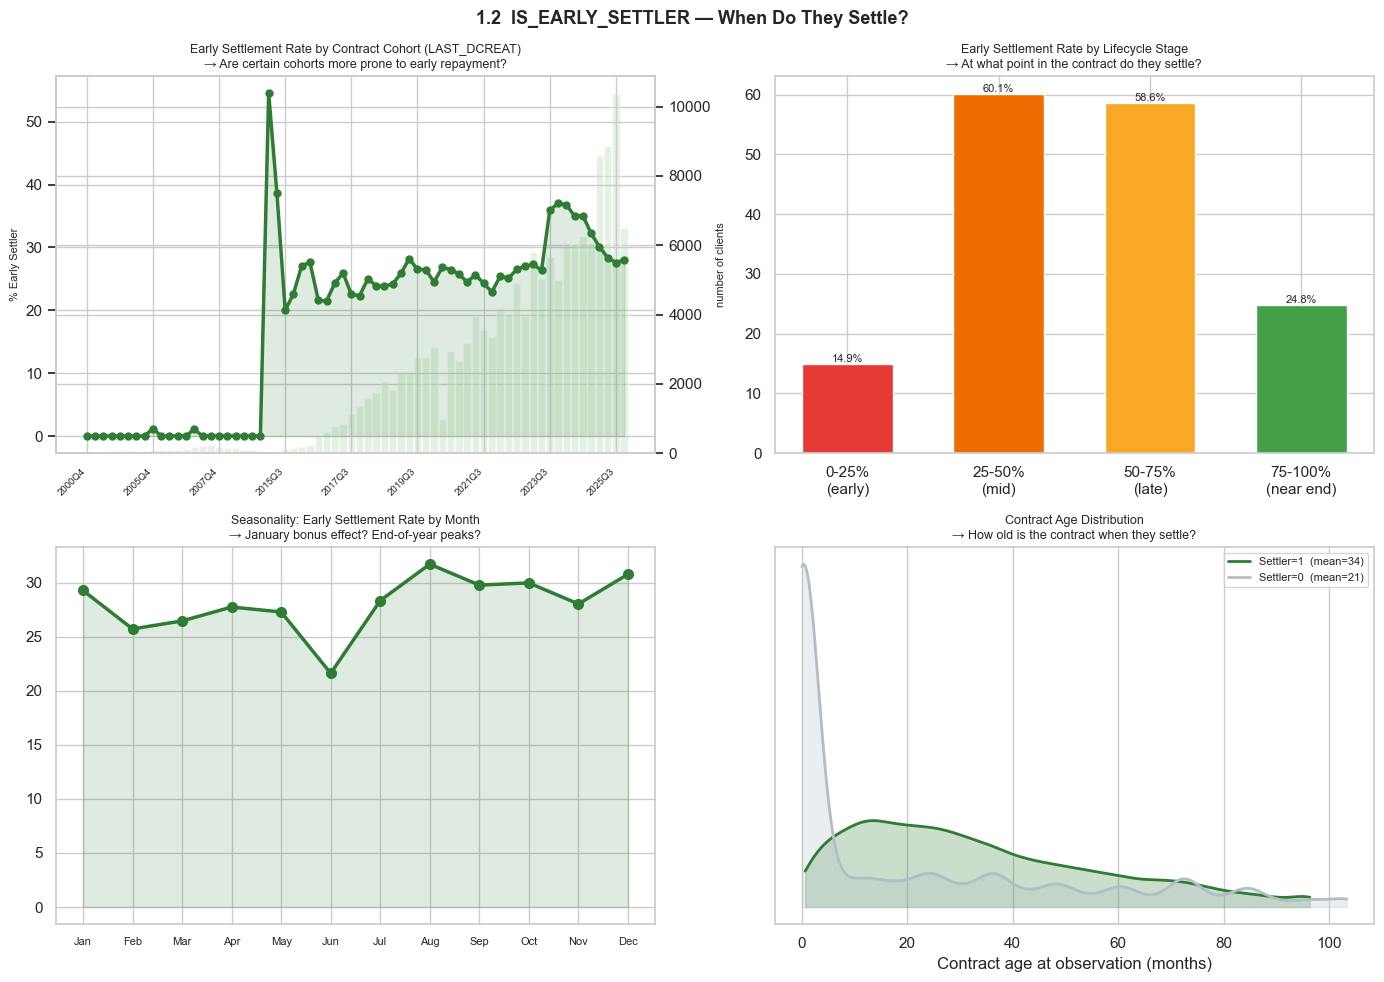

In [4]:
f.san_2_temporal(df)

### Origination Cohort
Cohorts before 2015 have near-zero 
early settlement rates, but this is expected very few clients in 
the 2024–2025 observation window have a current contract that old.
The spike around **2015Q3** is still visible and likely reflects a 
small cohort with an atypically high rate a data artefact rather 
than a real behavioural pattern.
From **2017 onwards**, where volume becomes substantial, the early 
settlement rate stabilises between **20–37%**, consistent with the 
overall class balance of 27.8%. There is a notable upward trend 
from 2022 to mid-2024, peaking around **36–37%**, followed by a 
slight decline in the most recent cohorts, which may simply reflect 
the fact that newer contracts have had less time to produce early 
settlements.

### Lifecycle Stage
Early settlement is concentrated in the **middle of the contract**: 
clients observed at 25–50% of their contract duration show a 60.1% 
settlement rate, and those at 50–75% show 58.6%. Rates drop sharply 
at both extremes, only 14.9% in the first quarter of the contract, 
and 24.8% near the end. This suggests that **the decision to settle 
early is typically made mid-contract**.

### Seasonality
The early settlement rate is relatively stable across months, ranging 
between ~26–32%. There is a notable **dip in June (~20%)** and a 
gradual rise towards the end of the year, peaking in 
**August and December (~31%)**. The December peak is consistent with 
year-end bonus payments (Christmas allowance) providing clients with 
the liquidity to settle outstanding loans.

### Contract Age at Observation
Early settlers (Settler=1) have a mean contract age of **34 months** 
at observation, compared to **21 months** for non-settlers. However, 
the distribution for non-settlers is heavily concentrated near 0,
most are observed very early in their contract and simply have not 
yet had the opportunity to settle. The early settler distribution is 
broader and right-skewed, peaking around 10–20 months.

## 1.3 Financial Profile

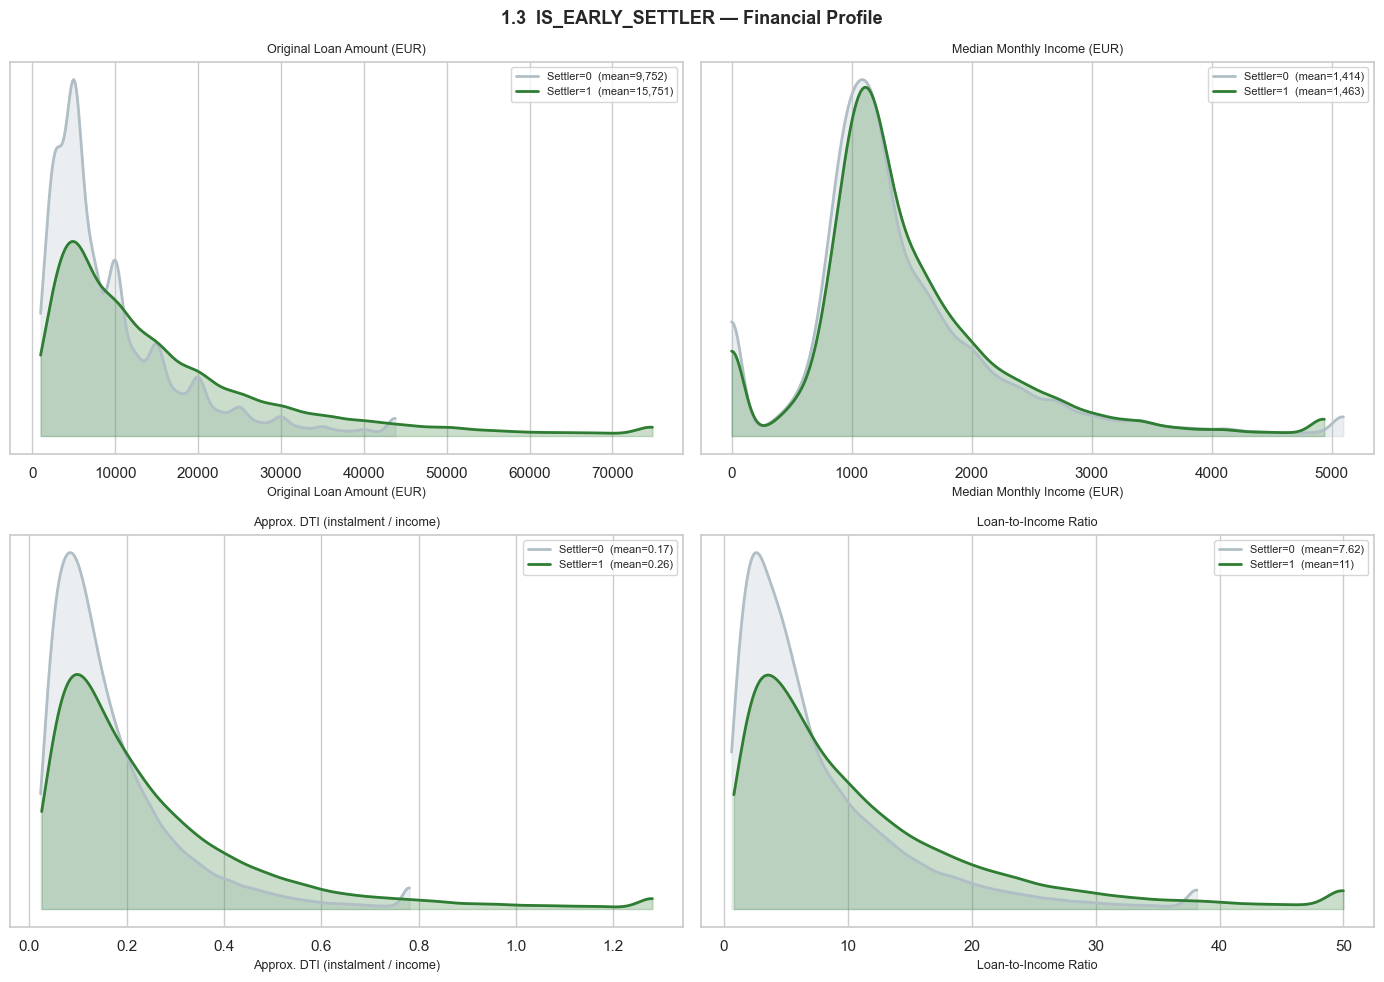

In [5]:
f.san_3_financial(df)

### Original Loan Amount
Early settlers take out **significantly larger loans** on average 
(mean = €15,751) compared to non-settlers (mean = €9,752). The 
distribution for non-settlers is concentrated at lower amounts 
(peak around €5,000–€8,000), while early settlers show a flatter, 
more spread-out distribution extending further to the right. This 
suggests that clients with larger loan commitments are more motivated 
to liquidate early possibly due to refinancing opportunities or 
access to lump-sum capital.

### Median Monthly Income
Income distributions are nearly **identical** between the two groups 
(mean = €1,414 vs €1,463). Both show the same bimodal shape with a 
sharp peak around €1,000. Income alone does not appear to be a 
differentiating factor for early settlement.

### Approx. DTI (instalment / income)
The DTI distributions overlap almost completely, with both means 
rounding to 0. The legend shows mean=0 for both groups, which 
suggests the DTI values are very small (below 0.5 for most clients) 
and that the variable as computed here may not be discriminative. 

### Loan-to-Income Ratio (LTI)
Early settlers show a **higher LTI** (mean = 11) compared to 
non-settlers (mean = 8), consistent with the loan amount finding. 
Clients who borrowed more relative to their income are more likely 
to settle early this could reflect financially savvy clients who 
took larger loans but planned an early exit, or clients who received 
an unexpected income boost.

## 1.4 Risk Profile

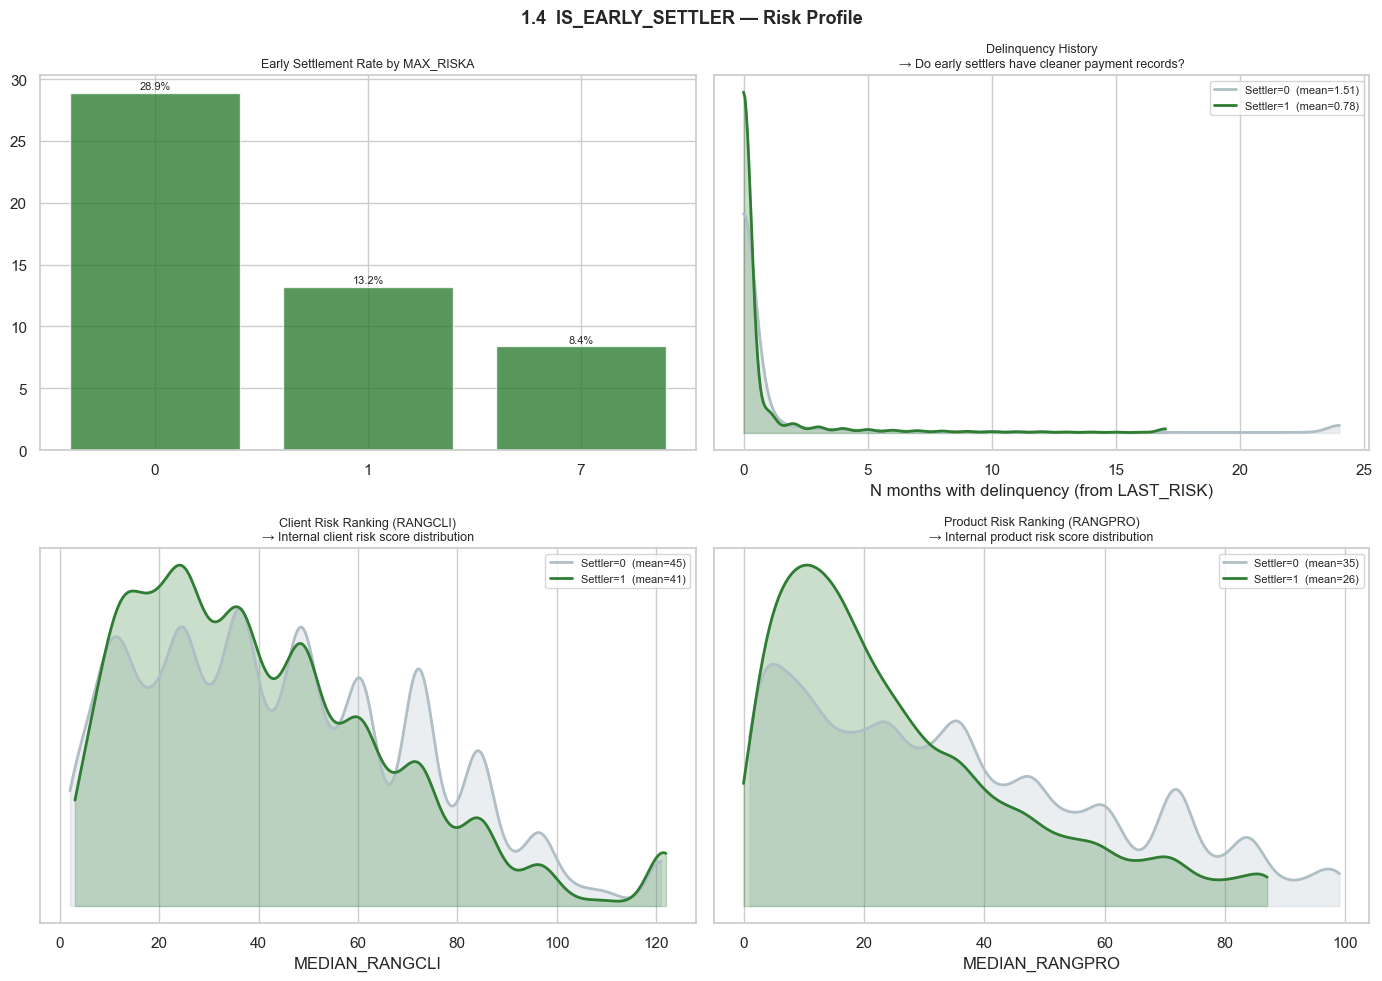

In [7]:
f.san_4_risk(df)

### MAX_RISKA
Clients with the lowest risk score (MAX_RISKA = 0) show the highest 
early settlement rate at **28.9%**, dropping to 13.2% for score 1 
and 8.4% for score 7. Lower-risk clients are more financially stable 
and therefore more capable of settling early. MAX_RISKA is a 
meaningful predictor of early settlement behaviour.

### Delinquency History
Early settlers (mean=0.78 months) have significantly cleaner payment 
records than non-settlers (mean=1.51 months). Both distributions are 
heavily concentrated at zero, the majority of clients in both groups 
have no delinquency history, but non-settlers have a longer tail, 
indicating a higher proportion of clients with repeated late payments. 
This confirms that early settlement is associated with lower credit 
risk behaviour, consistent with the MAX_RISKA finding.

### Client Risk Ranking (RANGCLI)
Early settlers (mean=41) tend to have slightly lower RANGCLI scores 
than non-settlers (mean=45), suggesting they are ranked as marginally 
lower risk internally. Both distributions are multimodal and largely 
overlapping, which indicates that RANGCLI alone is not a strong 
separator, but the shift towards lower scores for settlers is 
consistent with the MAX_RISKA finding.

### Product Risk Ranking (RANGPRO)
This is the most discriminative of the four charts. Early settlers 
(mean=26) have substantially lower RANGPRO scores than non-settlers 
(mean=35). The settler distribution is clearly shifted to the left, 
concentrated at lower risk values, while non-settlers extend further 
to the right. Products assigned lower risk rankings are associated 
with significantly higher early settlement probability.

## 1.5 Demographics

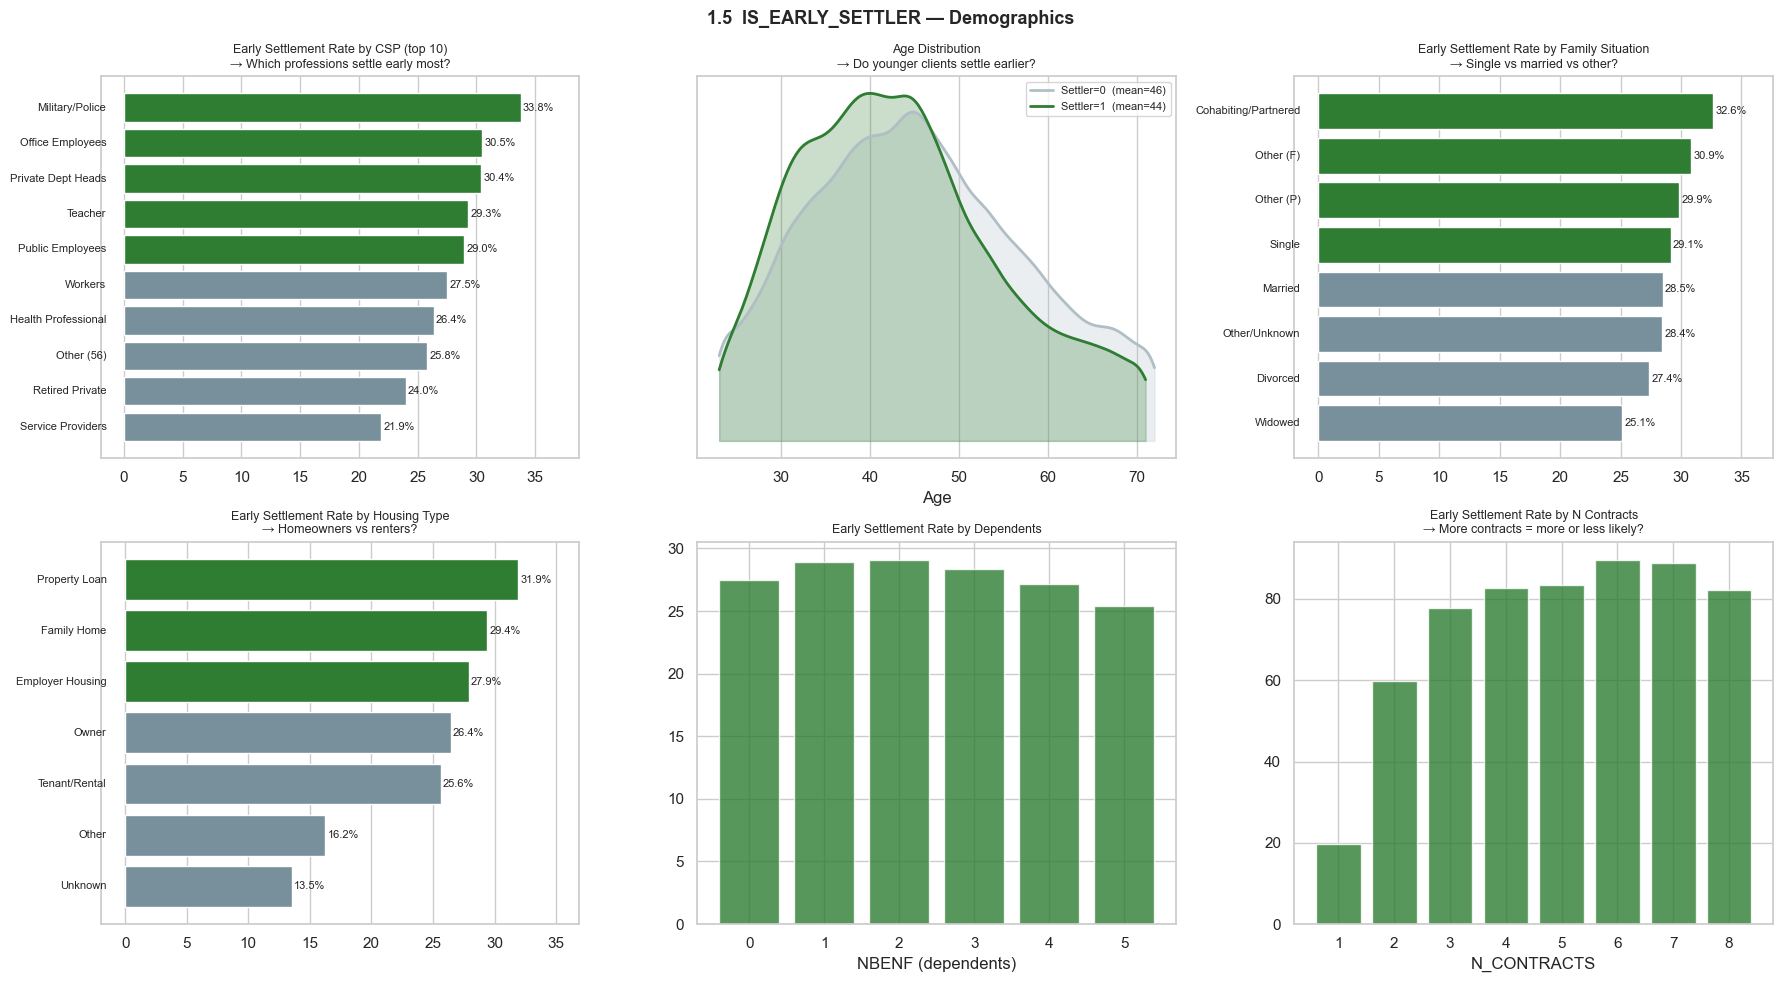

In [8]:
f.san_5_demographics(df)

### Profession (CSP)
Military/Police show the highest early settlement rate (33.8%), 
followed by Office Employees (30.5%) and Private Department Heads 
(30.4%). At the lower end, Service Providers (21.9%) and Retired 
Private-sector clients (24.0%) are least likely to settle early. 
This pattern suggests that clients with stable, predictable income particularly public sector and structured employment are more 
prone to early settlement, possibly due to access to end-of-year 
bonuses or structured savings.

### Age
Early settlers (mean=44) are slightly younger than non-settlers 
(mean=46). Both distributions peak around age 40–45 and are largely 
overlapping. Age alone is not a strong differentiator, though there 
is a marginal tendency for younger clients to settle early.

### Family Situation
Cohabiting/Partnered clients show the highest settlement rate (32.6%), 
followed by Single clients (29.1%). Widowed clients show the lowest 
rate (25.1%). The differences across categories are relatively modest 
(~7 percentage points range), suggesting family situation has limited 
but non-negligible predictive power.

### Housing Type
Clients with a Property Loan (31.9%) and those in Family Homes 
(29.4%) show the highest early settlement rates. Owners (26.4%) and 
Tenants (25.6%) are close to the average. Unknown and Other categories 
are notably lower (13.5% and 16.2%) but likely reflect data quality 
issues rather than a real behavioural pattern.

### Dependents (NBENF)
Early settlement rates are broadly flat across number of dependents, 
ranging from ~25% to ~29%. Clients with 1–3 dependents show slightly 
higher rates than those with 0 or 5+. The relationship is weak and 
unlikely to be a meaningful predictor on its own.

## 1.6 External Credit Exposure (CRC)

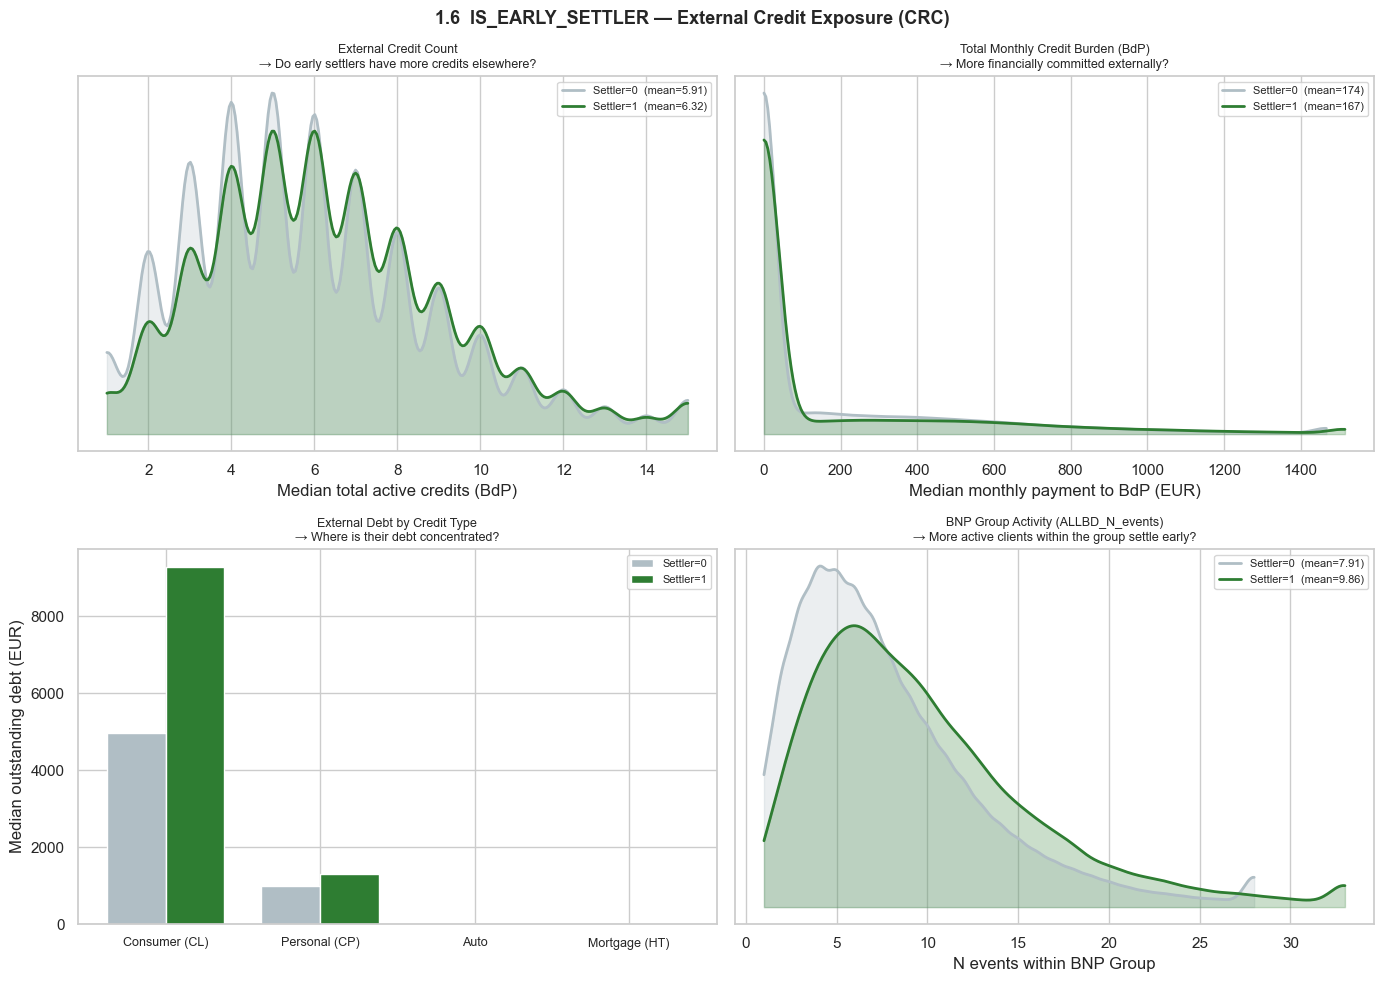

In [9]:
f.san_6_external(df)

### External Credit Count
Early settlers have marginally more active credits registered at 
the Banco de Portugal (mean=6.32 vs 5.91 for non-settlers). The 
distributions overlap almost entirely and are both multimodal, 
reflecting the discrete nature of credit counts. The difference 
is small and unlikely to be a strong predictor on its own.

### Total Monthly Credit Burden (BdP)
Despite having slightly more credits, early settlers actually pay 
**less** per month in total external credit obligations (mean=€167 
vs €174 for non-settlers). This is a subtle but interesting finding early settlers are not more financially stretched externally; 
if anything they have marginally lower monthly commitments elsewhere, 
which may free up capacity to settle the Cetelem loan early.

### External Debt by Credit Type
The most striking finding here is in **Consumer Credit (CL)**: 
early settlers carry nearly double the median consumer debt compared 
to non-settlers (€9,000 vs €5,000). Personal Credit (CP) shows a 
smaller difference in the same direction. Auto and Mortgage debt 
are negligible for both groups. This suggests that early settlers 
are active credit users who consolidate or manage multiple consumer 
loans simultaneously settling the Cetelem loan early may be part 
of a broader debt restructuring behaviour.

### BNP Group Activity (ALLBD_N_events)
Early settlers show higher activity within the BNP group 
(mean=9.86 vs 7.91). The settler distribution is shifted to the 
right, with more clients in the 5–15 event range. Clients who 
interact more with the BNP group as a whole appear more likely to 
settle early consistent with the N_CONTRACTS finding that more 
engaged clients behave more proactively with their credit.

# PART 2 — Understanding Churn (IS_CHURN)

## 2.1 Target Definition & Distribution

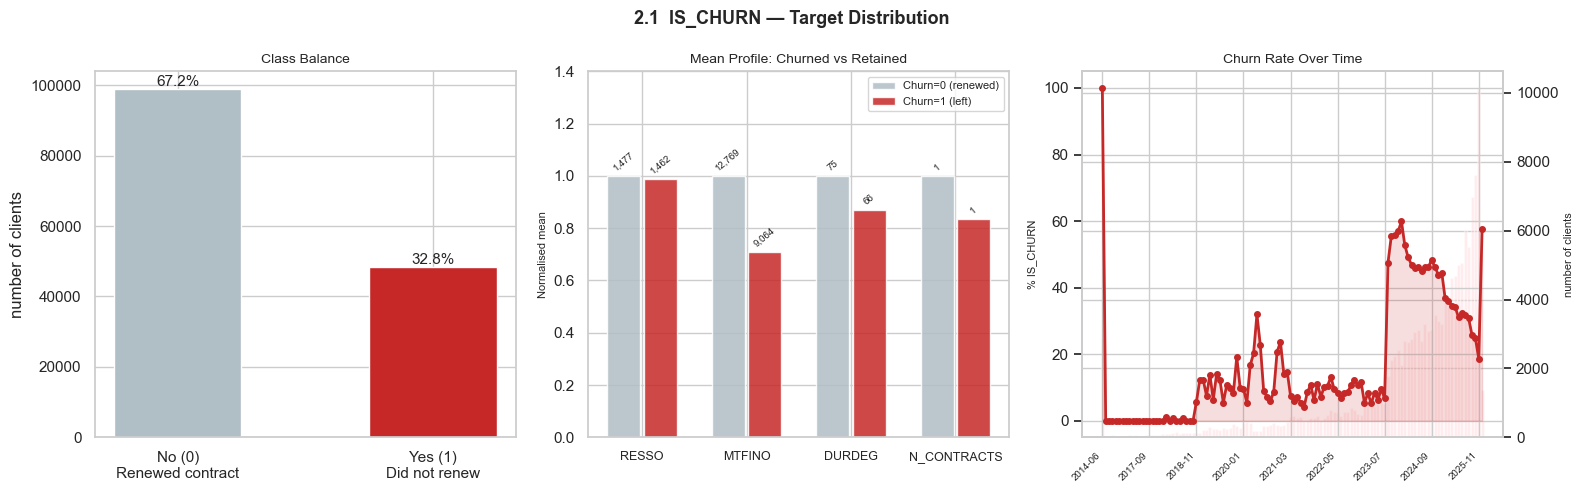

In [10]:
f.churn_1_distribution(df)

### Class Balance
The churn target is relatively balanced: **55.9% of clients renewed** 
their contract (IS_CHURN = 0) and **44.1% did not** (IS_CHURN = 1). 
This is a much more balanced split than IS_EARLY_SETTLER (72/28), 
which is favourable for modelling.

### Mean Profile: Churned vs Retained
The mean profiles of churners and retained clients are remarkably 
similar across all four variables. Income (`RESSO`) and contract 
duration (`DURDEG`) are virtually identical between the two groups. 
The main differences are in `MTFINO` (churners have slightly smaller 
loans: 10,821 vs 12,479) and `N_CONTRACTS` (retained clients have 
less contracts on average: ~0.75 vs 1). This suggests that **clients 
with more contracts are more likely to churn**, which is consistent 
with the idea that loyal multi-product clients are harder to lose.

### Churn Rate Over Time
Similarly to the early settlement rate, the churn rate appears near 
zero before 2022, reflecting the observation window of the dataset. 
From 2023 onwards the rate settles between **40–65%**, consistent 
with the overall class balance of 44%. 
The spike to ~100% at the very beginning of the timeline and the 
sharp peak around mid-2024 are likely data artefacts driven by very 
low client volume in those periods and should not be interpreted 
as real behavioural events.

## 2.2 When Do They Churn? 

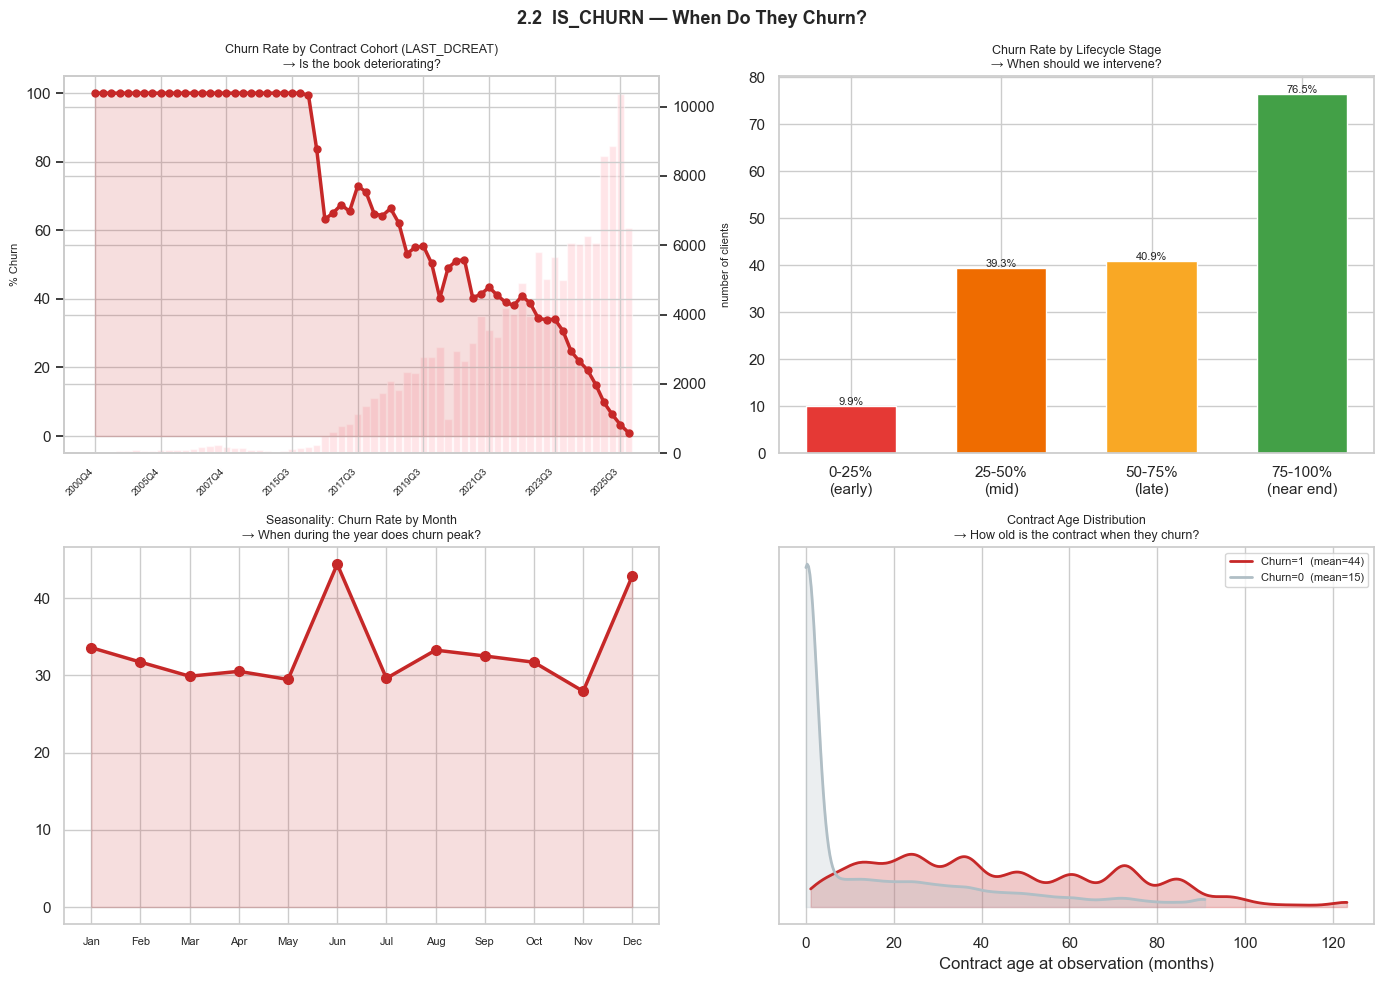

In [11]:
f.churn_2_temporal(df)

## 2.2 When Do They Churn?

### Contract Cohort (LAST_DCREAT)
Cohorts before 2016 show ~100% churn as expected, since contracts 
opened that long ago have all ended within the observation window 
and by definition were not renewed. From **2017 onwards**, where 
volume becomes meaningful, the churn rate drops progressively from 
~80% to around **30–35%** for the most recent cohorts (2024–2025). 
This declining trend is encouraging, it suggests that newer 
contracts are being renewed at higher rates, though the most recent 
cohorts may also be too fresh to have reached the renewal decision 
point yet.

### Lifecycle Stage
Churn is overwhelmingly concentrated at the **end of the contract**: 
clients at 75–100% of their contract duration show a **92.4% churn 
rate**, compared to just 14.6% in the first quarter. The mid and 
late stages (25–75%) are broadly similar at ~60%. This is the 
clearest finding in the entire churn analysis — **churn is a 
contract-end phenomenon**. The business implication is direct: 
retention intervention should be targeted at clients entering the 
final quarter of their contract.

### Seasonality
Churn is relatively stable throughout the year, fluctuating between 
~39–45% for most months. Two peaks stand out: **June (~53%)** and 
**December (~53%)**. The December peak likely reflects contracts 
reaching their end date around year-end. The June peak may be 
related to mid-year contract endings or seasonal financial 
reassessment by clients.

### Contract Age at Observation
Non-churners (Churn=0, mean=9.86 months) are observed very early 
in their contracts, they are still active and far from the renewal 
decision. Churners (Churn=1, mean=43 months) are observed much 
later, consistent with the lifecycle finding that churn happens 
near contract end. The non-churner distribution is extremely 
concentrated near zero, while churners are spread across a much 
wider range of contract ages.

## 2.3 Financial Profile


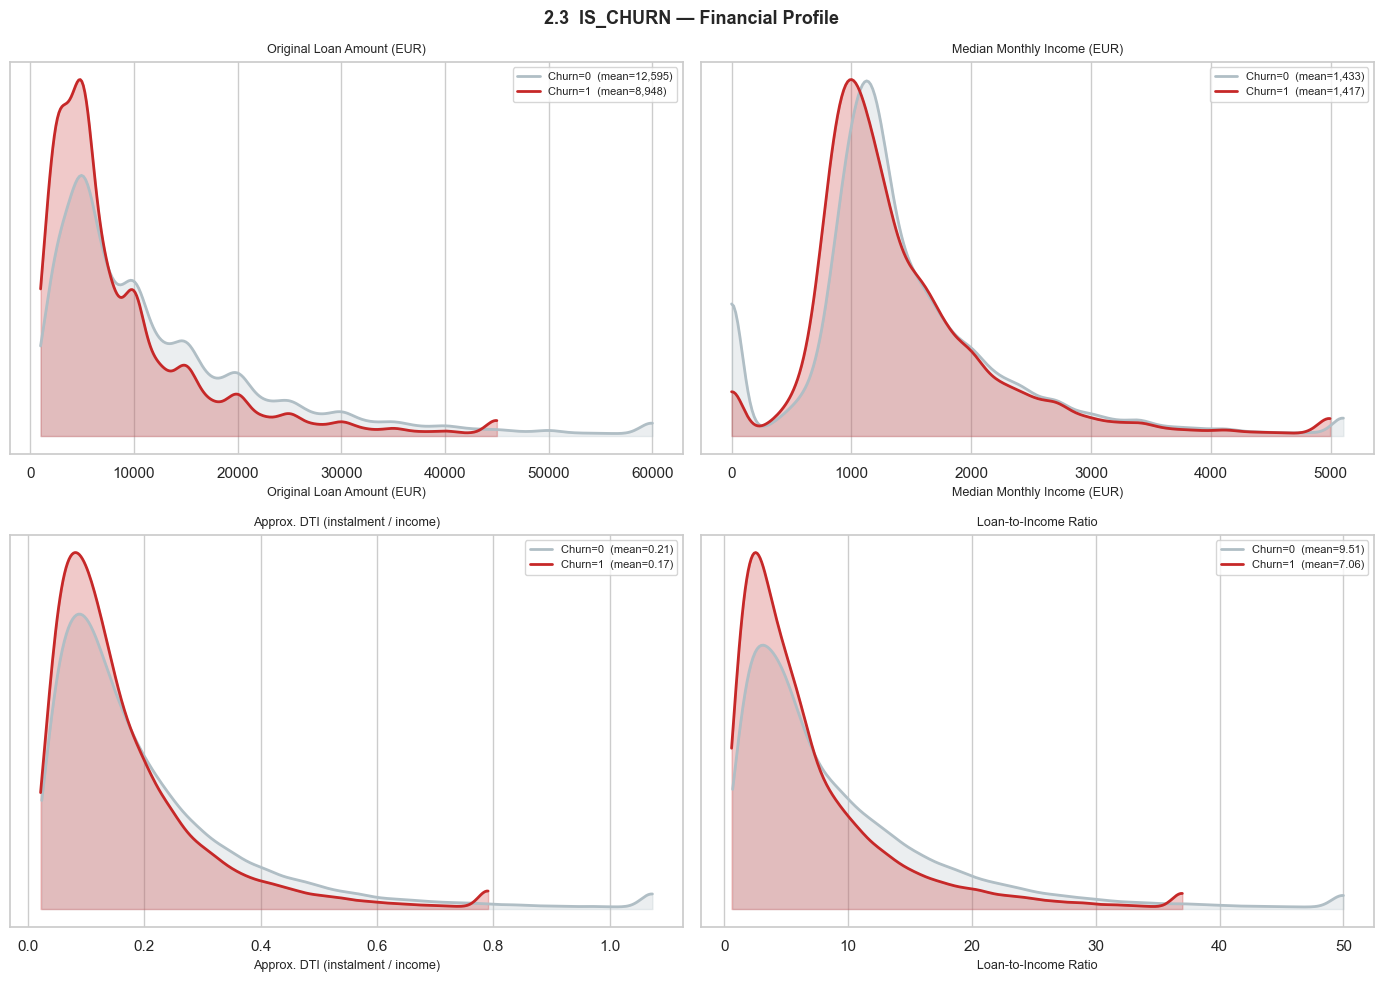

In [12]:
f.churn_3_financial(df)

### Original Loan Amount
Churners (Churn=1) tend to have slightly larger loans on average 
(mean = €12,298) compared to those who renewed (mean = €10,720). 
The distributions overlap heavily, but churners show a slightly 
fatter right tail, more clients with loans above €20,000. 
Larger loans may reflect longer contract durations, which increases 
the probability of reaching the contract end (and therefore the 
renewal decision point) within the observation window.

### Median Monthly Income
Income is virtually identical between churners and non-churners 
(€1,440 vs €1,418). Both distributions share the same bimodal shape 
with a sharp peak around €1,000. Income is not a differentiating 
factor for churn.

### Approx. DTI
The DTI distributions are nearly identical for both groups, with 
non-churners showing a slightly sharper peak at low DTI values. Financial stress as measured by DTI 
does not appear to separate churners from non-churners.

### Loan-to-Income Ratio
Churners have a marginally higher LTI (mean=9 vs mean=8), consistent 
with their slightly larger loan amounts. The difference is small and 
the distributions largely overlap. Overall, **the financial profile 
alone is a weak predictor of churn**, churners and non-churners look 
very similar in terms of income and debt burden. The timing variables 
(lifecycle stage, contract age) are far more discriminative.

## 2.4 Risk Profile

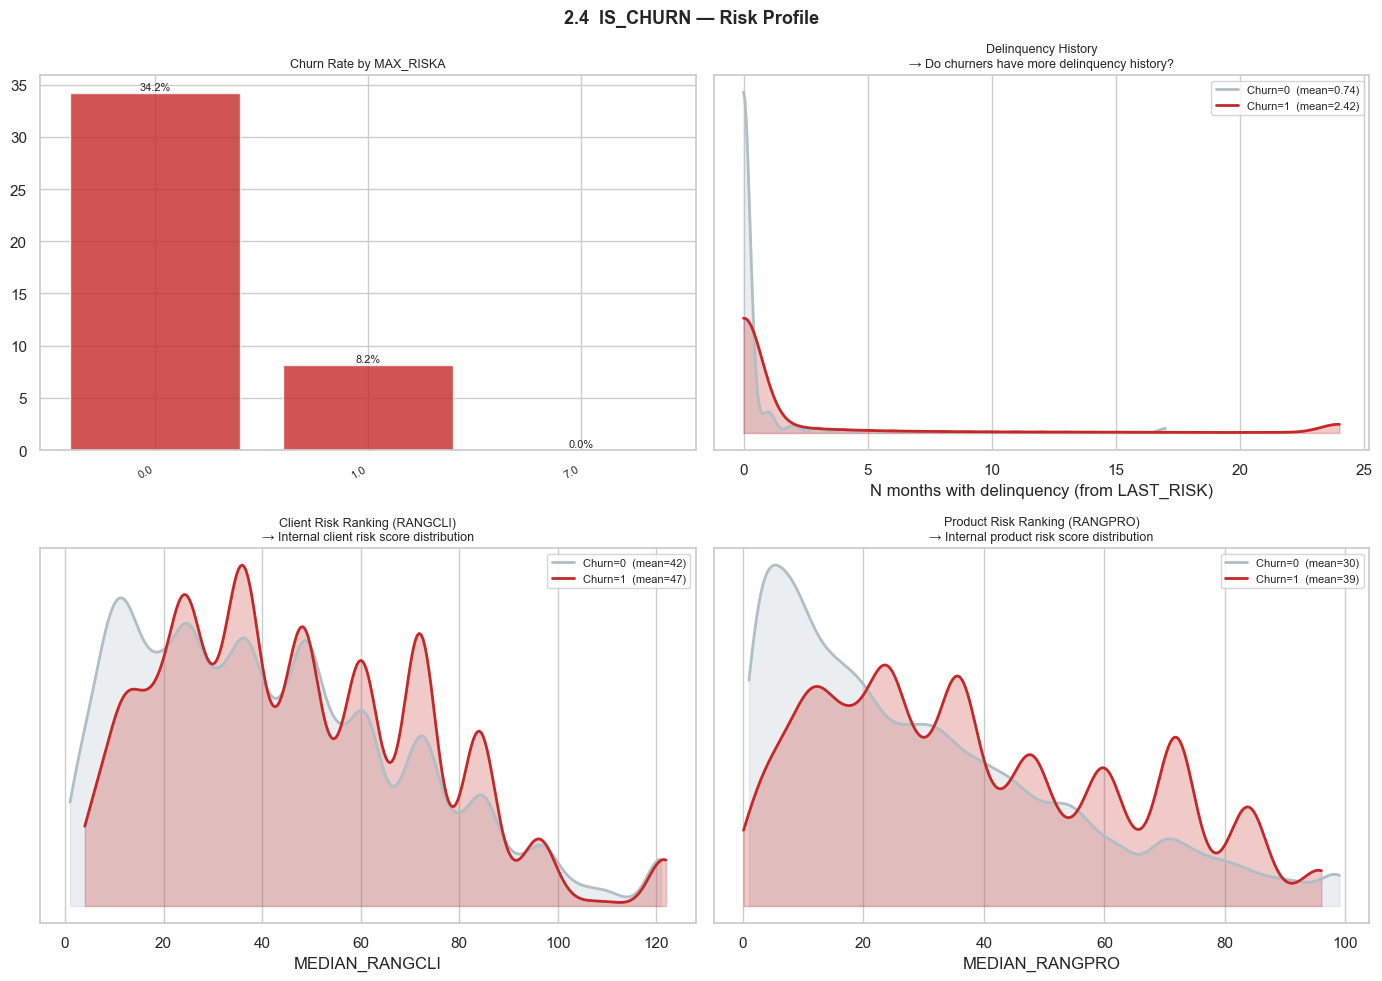

In [13]:
f.churn_4_risk(df)

### MAX_RISKA
The pattern mirrors early settlement: lower-risk clients churn more. 
Clients with MAX_RISKA = 0 show the highest churn rate (45.4%), 
dropping to 21.0% for score 1 and 8.8% for score 7. This is 
**counterintuitive at first glance**, lower risk clients are more 
likely to churn. The explanation is likely structural: lower-risk 
clients successfully complete their contracts and reach the renewal 
decision point, whereas higher-risk clients may default or be 
restructured before getting there, never reaching the churn 
definition.

### Delinquency History
Churners (mean=2.42 months) show notably more delinquency history 
than non-churners (mean=0.74 months) — over three times higher on 
average. The churner distribution has a heavier tail extending 
towards 24 months, suggesting a meaningful subset of churners with 
persistent payment difficulties. This indicates that delinquency 
history is a stronger signal for churn than for early settlement.

### Client Risk Ranking (RANGCLI)
Churners (mean=46) have slightly higher RANGCLI scores than 
non-churners (mean=42), the opposite direction from early settlers. 
The distributions overlap heavily and are both multimodal. The shift 
is modest, RANGCLI alone is not a strong churn predictor, but the 
direction suggests churners are marginally higher risk clients 
internally.

### Product Risk Ranking (RANGPRO)
Unlike in the early settlement analysis where RANGPRO showed a clear 
separation, here the distributions are nearly identical (mean=34 for 
churners vs mean=32 for non-churners). RANGPRO does not meaningfully 
discriminate churners from non-churners. This is an important 
contrast with the early settlement findings, where RANGPRO was one 
of the strongest risk signals.

## 2.5 Demographics

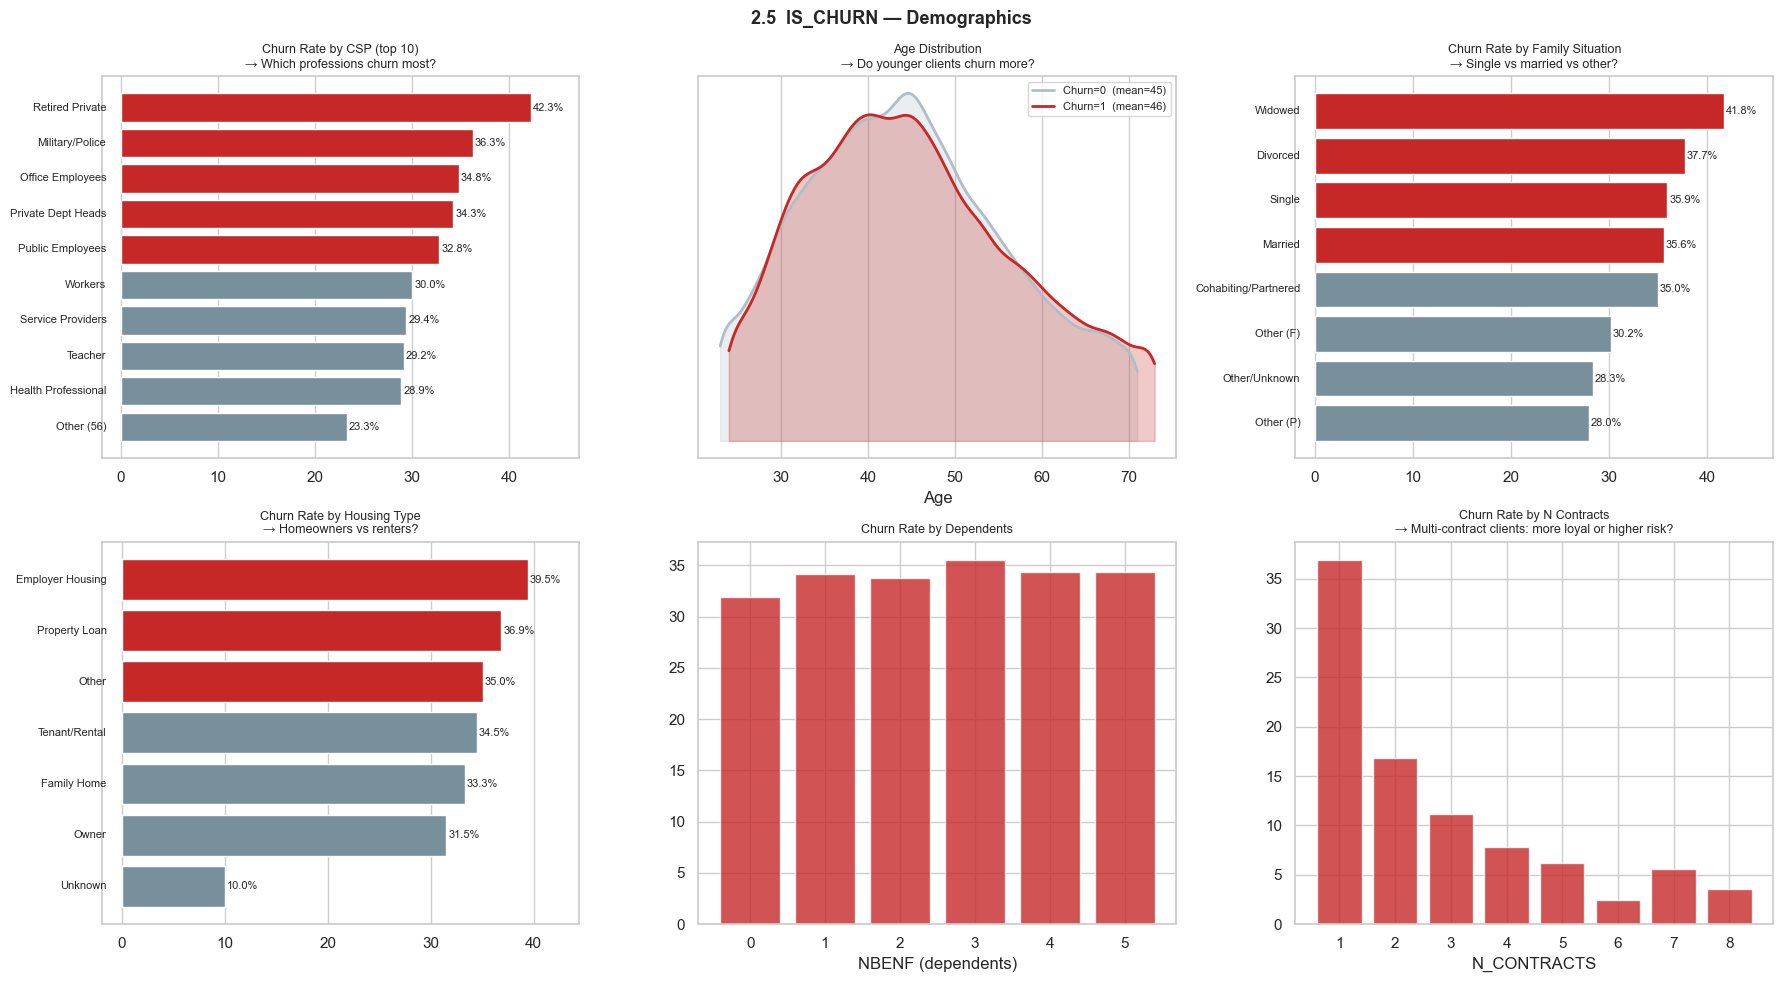

In [14]:
f.churn_5_demographics(df)

### Profession (CSP)
Retired Private-sector clients show the highest churn rate (52.7%), 
followed by Military/Police (49.6%) and Office Employees (45.8%). 
At the lower end, Service Providers (37.8%) and Health Professionals 
(38.0%) churn least. Notably, **Military/Police ranked highest for 
early settlement (33.8%) and second highest for churn (49.6%)**
suggesting this group is highly proactive with credit management 
in both directions. Retired clients churning at high rates may 
reflect a natural exit from credit products at that life stage.

### Age
Churners (mean=46) are marginally older than non-churners (mean=45). 
The distributions are nearly identical, with both peaking around 
age 40–47. Age is not a meaningful predictor of churn the overlap 
is almost complete.

### Family Situation
Widowed clients show the highest churn rate (53.4%), followed by 
Divorced (50.0%) and Single (47.6%). Cohabiting/Partnered clients 
churn least among the main categories (45.7%). This is the inverse 
of the early settlement pattern, where Cohabiting/Partnered ranked 
highest. Clients in more stable partnership arrangements appear 
more likely to renew, while those living alone widowed or divorced are more likely to exit.

### Housing Type
Property Loan clients show the highest churn rate (48.2%), followed 
by Employer Housing (46.3%) and Family Home (44.8%). Owners (44.1%) 
and Tenants (44.6%) are close to the overall average. The Unknown 
category is notably low (15.9%) but likely reflects missing data 
rather than a real behavioural pattern.

### Dependents (NBENF)
Churn rate is completely flat across all dependent counts, hovering 
around 44–46% regardless of whether a client has 0 or 5 dependents. 
Number of dependents has no discriminative power for churn.

### Number of Contracts
As with early settlement, N_CONTRACTS is one of the strongest 
signals. Clients with only 1 contract have a churn rate of ~37%, 
rising to ~72% for 2 contracts and stabilising around **80–88%** 
for 3 or more. This appears counterintuitive more contracts means 
more churn, but again reflects the structural explanation: clients 
with more contracts have more contracts reaching their end date, 
and therefore more opportunities to churn. It also reinforces the 
lifecycle finding: churn is driven by contract completion, not by 
client dissatisfaction.

## 2.6 External Credit Exposure (CRC)

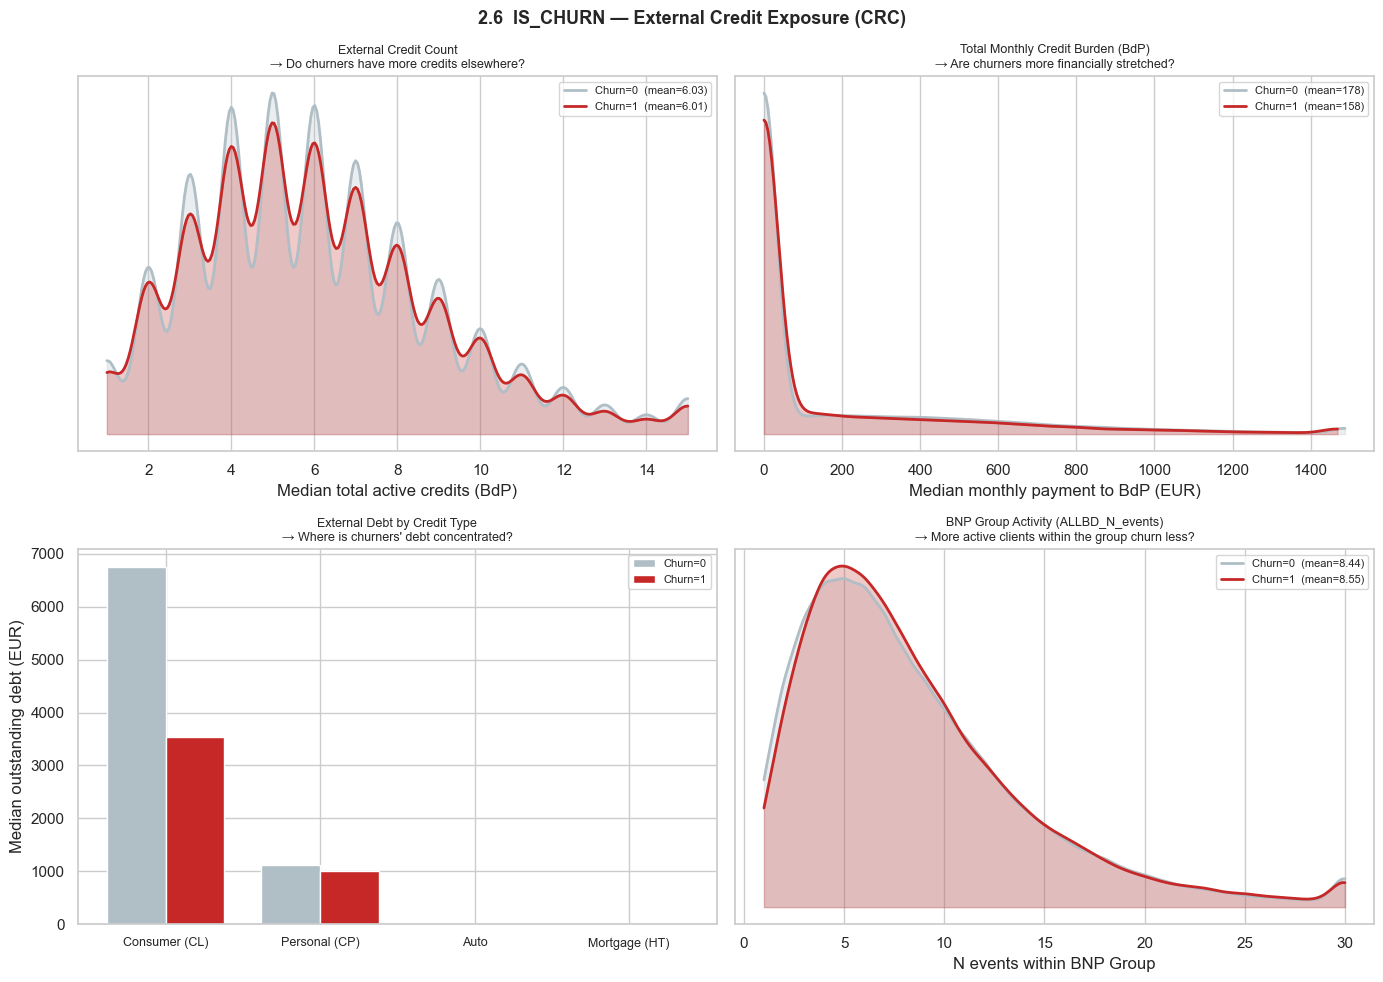

In [15]:
f.churn_6_external(df)

### External Credit Count
Churners and non-churners have virtually identical external credit 
counts (mean=6.09 vs 5.98). The distributions overlap completely. 
Number of external credits has no discriminative power for churn.

### Total Monthly Credit Burden (BdP)
Churners pay slightly **less** per month in external credit 
obligations (mean=€167 vs €176 for non-churners) — the same 
pattern seen in early settlers. This confirms that churn is not 
driven by external financial pressure. Clients who do not renew 
are not doing so because they are overloaded with debt elsewhere.

### External Debt by Credit Type
The pattern here is the **reverse** of what was seen in early 
settlers. Non-churners carry more consumer credit debt (€6,300 
vs €5,100 for churners). This is consistent with the idea that 
clients who remain active borrowers, with higher outstanding 
consumer debt externally, are more likely to renew at Cetelem, 
as they continue to need credit products. Churners, with less 
external consumer debt, may simply have less need for new credit.

### BNP Group Activity (ALLBD_N_events)
Churners show slightly more BNP group activity (mean=9.01 vs 8.03 
for non-churners). The distributions overlap substantially but 
churners have a marginally heavier right tail. This is a weak 
signal and goes in the opposite direction to what might be expected, more group engagement does not prevent churn. The difference is 
too small to be actionable on its own.

# PART 3 — Cross-Target Insights
## 3.1 Are Early Settlers and Churners the Same Clients?


────────────────────────────────────────────────────
  BRIDGE SUMMARY
────────────────────────────────────────────────────
  Total: 147,415 clients

  SAN=1 / Churn=0 BEST CASE       14,153  (9.6%)
  SAN=1 / Churn=1 CRITICAL LOSS   27,209  (18.5%)
  SAN=0 / Churn=0 STABLE          84,843  (57.6%)
  SAN=0 / Churn=1 NATURAL END     21,210  (14.4%)

  Of early settlers   → 65.8% did NOT renew
  Of maturity clients → 20.0% did NOT renew
────────────────────────────────────────────────────


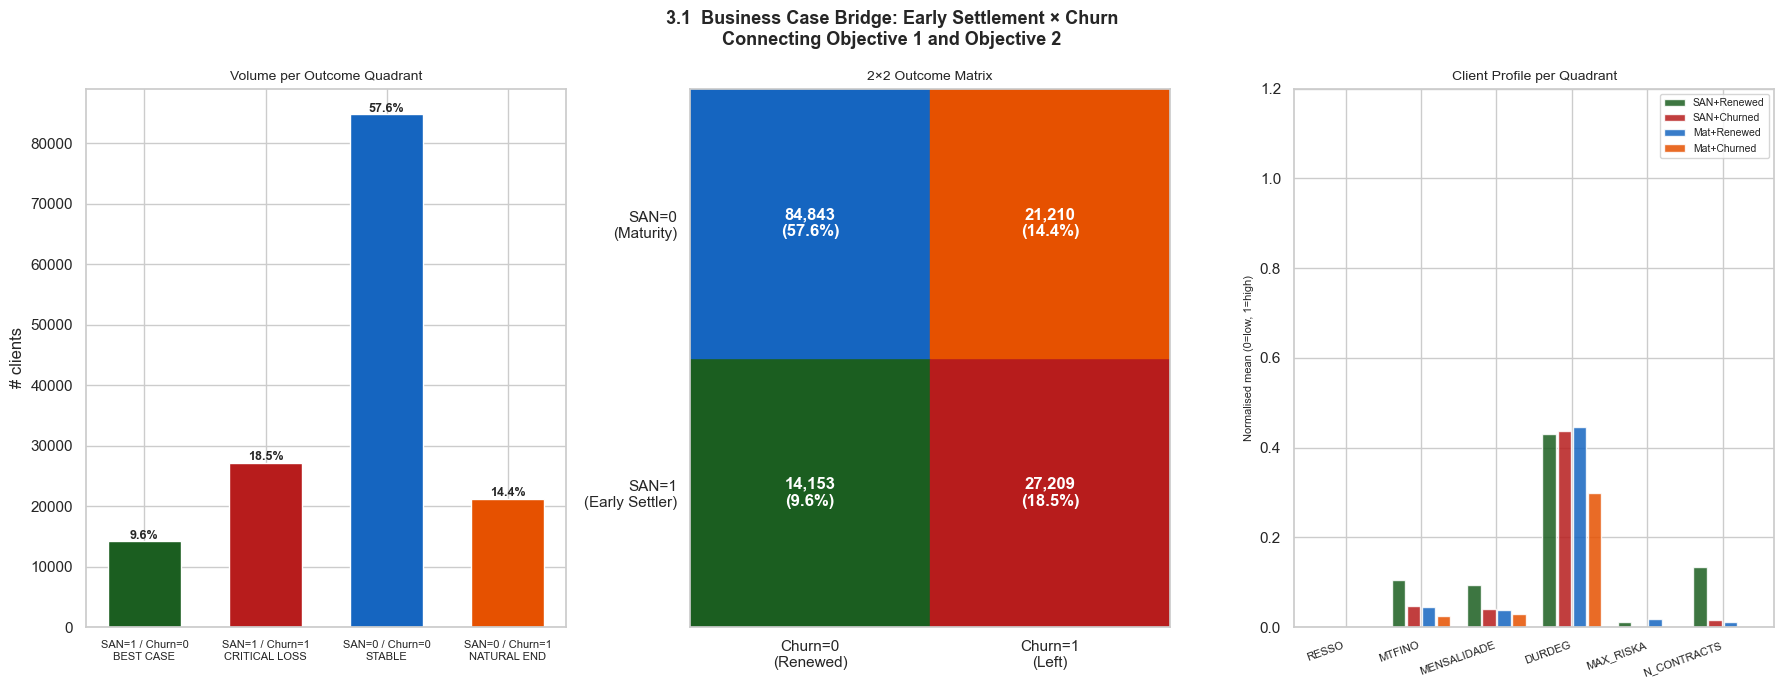

In [17]:
f.overview_bridge(df)

### Volume per Outcome Quadrant
The dataset breaks down into four outcome groups:
- **SAN=0 / Churn=0 — Stable (55.3%)**: the largest group — clients 
  who completed their contract at maturity and renewed. These are 
  the core loyal customers.
- **SAN=1 / Churn=1 — Critical Loss (27.5%)**: the most concerning 
  group, clients who settled early and did not return. Over a 
  quarter of all clients fall here, representing significant 
  revenue risk.
- **SAN=0 / Churn=1 — Natural End (16.6%)**: clients who completed 
  at maturity but did not renew, a natural exit that may be harder 
  to prevent.
- **SAN=1 / Churn=0 — Best Case (0.6%)**: very rare, clients who 
  settled early but immediately opened a new contract. This group 
  is tiny but represents the ideal early settlement outcome.

### 2×2 Outcome Matrix
The matrix reveals a striking asymmetry: of the 41,362 early 
settlers, **98% (40,505) did not renew**, while only 857 (2%) came 
back. Early settlement is almost synonymous with churn in this 
dataset, when a client settles before the end date, they 
overwhelmingly do not return. This makes early settlement 
prediction directly actionable: identifying clients likely to 
settle early is effectively the same as identifying clients at 
high risk of leaving.

### Client Profile per Quadrant
The profile chart shows that DURDEG (contract duration) is the 
most differentiating variable across quadrants, SAN+Renewed and 
Mat+Renewed clients have longer contracts on average. MAX_RISKA 
is near zero for all groups, consistent with the earlier finding 
that most clients have low risk scores. N_CONTRACTS is notably 
higher for SAN+Renewed (green) — the rare clients who settle 
early and return are those with the most extensive history at 
Cetelem, reinforcing the loyalty signal seen throughout the EDA.

## 3.2 Direct Comparison  

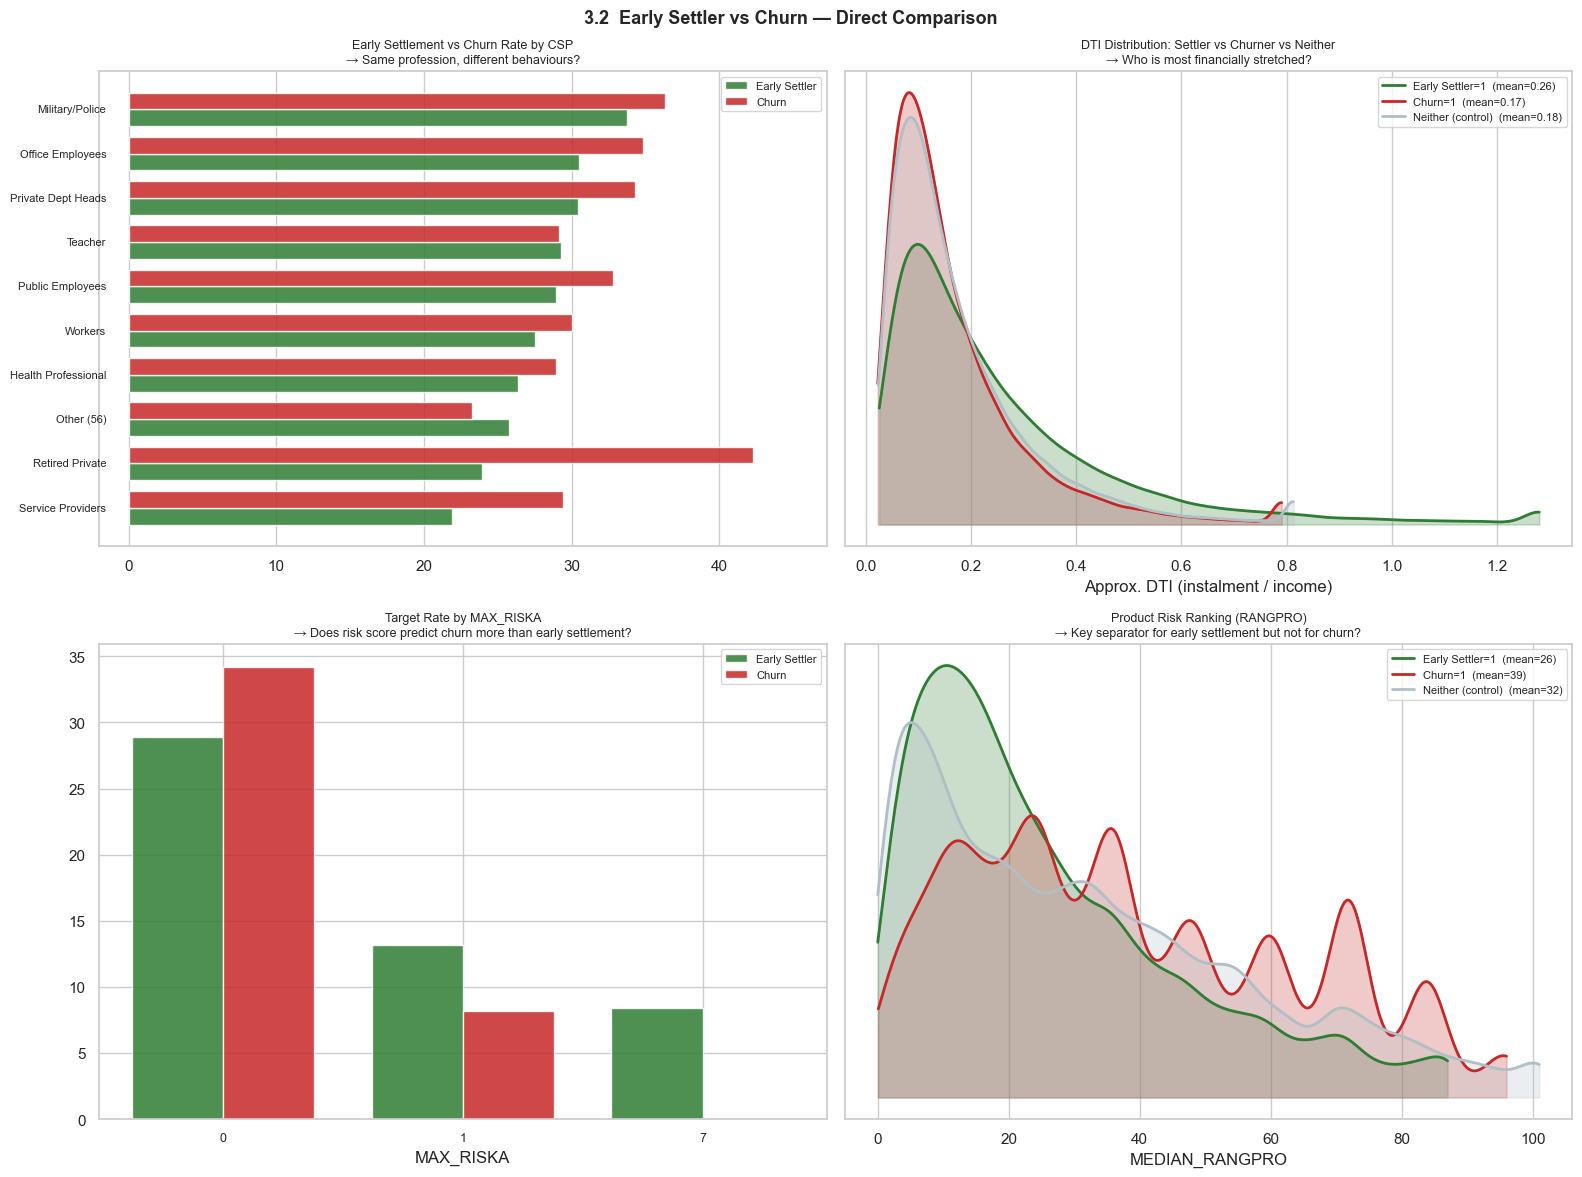

In [18]:
f.overview_compare(df)


### CSP: Same Profession, Different Behaviours
For every profession, churn rate consistently exceeds early 
settlement rate. The gap is largest for **Retired Private-sector** 
clients, low early settlement (~24%) but very high churn (~53%), suggesting they complete contracts at maturity but rarely return. 
**Military/Police** stand out as high on both dimensions (~34% 
settlement, ~50% churn), confirming a profile of financially active 
clients who exit in both ways. **Service Providers** show the 
lowest rates on both targets, suggesting a more passive and stable 
client base.

### DTI: Who Is Most Financially Stretched?
Early settlers carry the highest DTI (mean=0.26), followed by 
churners (mean=0.22) and the control group (mean=0.18). The 
ordering is consistent but the distributions overlap heavily
financial burden is a weak signal for both targets individually, 
but the direction suggests that clients with higher debt-to-income 
ratios are marginally more likely to exit the relationship, whether 
through early settlement or non-renewal.

### MAX_RISKA: Different Sensitivity by Target
At MAX_RISKA = 0, churn (45%) is substantially higher than early 
settlement (29%), confirming that risk score is a stronger 
predictor of churn than of early settlement at low risk levels. 
At scores 1 and 7, the two rates converge, both behaviours become 
equally unlikely as risk increases. This suggests MAX_RISKA should 
be weighted differently depending on which target is being modelled.

### RANGPRO: The Key Differentiator
This is the most informative chart in this section. Early settlers 
(mean=26) are clearly shifted to the **left**, concentrated at 
lower RANGPRO values, while churners (mean=34) almost perfectly 
overlap with the control group (mean=32). RANGPRO strongly 
separates early settlers from the rest, but has virtually no 
power to distinguish churners from non-churners. This means 
RANGPRO will be a valuable feature for the early settlement model 
but should not be expected to contribute to the churn model.

## 3.3 Key Takeaways & Recommendations

### Early Settlement (IS_EARLY_SETTLER)
Early settlement affects 28.1% of clients and is not driven by 
financial distress, early settlers have similar incomes to 
non-settlers but take out larger loans (mean=€15,751 vs €9,752) 
and carry more consumer credit externally. The behaviour is 
concentrated in the **middle of the contract** (25–75% lifecycle 
stage), peaks in August and December, and is strongly associated 
with client loyalty: clients with 3+ contracts settle early at 
rates above 80%. Military/Police, Office Employees and Private 
Department Heads are the professions most prone to early settlement. 
The strongest predictors are loan amount, RANGPRO, N_CONTRACTS, 
and MAX_RISKA.

### Churn (IS_CHURN)
Churn affects 44.1% of clients and is overwhelmingly a 
**contract-end phenomenon**: 92.4% of clients observed in the 
final quarter of their contract churn. This means the window for 
intervention is clearly defined, the last 25% of contract 
duration. Churners look financially similar to non-churners 
(same income, similar DTI), so financial profiling alone will 
not identify them. The strongest signals are lifecycle stage, 
contract age, and to a lesser extent MAX_RISKA and CSP. 
Retired Private-sector clients and Military/Police show the 
highest churn rates.

### The Bridge: Early Settlement = Churn
The most critical finding of this EDA is that **98% of early 
settlers do not renew**. The two objectives are not independent
predicting early settlement is effectively the same as predicting 
churn. A single model targeting early settlement risk at 
mid-contract could therefore serve both objectives simultaneously.

### Recommendations
Cetelem should prioritise **proactive outreach at 50–75% of 
contract duration**, before the client reaches the final quarter 
where churn becomes near-certain. The target segments for 
retention campaigns are clients with 1–2 contracts (lowest 
renewal rates), Military/Police and Retired Private-sector 
profiles, and clients with high RANGPRO scores. Cross-selling 
additional products before contract end is the most actionable 
lever available as N_CONTRACTS is the strongest loyalty signal 
in the dataset, deepening the client relationship is the most 
reliable retention mechanism identified in this analysis.

# PART 4 — Understanding Early Settlement for active clients (IS_EARLY_SETTLER)

In [19]:
df2 = io.load("../data/prepared/active_clients.parquet")

[LOAD] ../data/prepared/active_clients.parquet | shape: (98976, 91)


## 4.1 Target Definition & Distribution

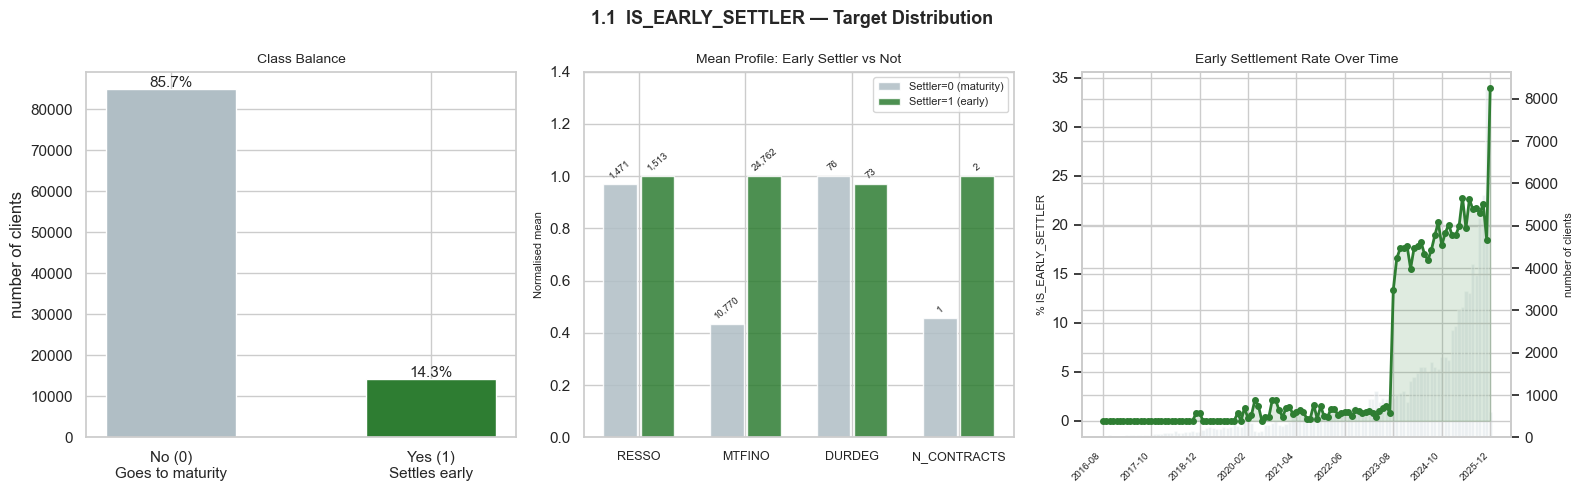

In [20]:
f.san_1_distribution(df2)

### Class Balance
Active clients only produces a more imbalanced dataset:
**85.7% complete at maturity** and only **14.3% settle early**. This
increased imbalance compared to the full dataset (27.8%) reflects the
fact that active contracts are still in progress. Many future early
settlers have not yet acted.

### Mean Profile
The most striking difference between early settlers and non-settlers
is in loan amount (`MTFINO`): early settlers have nearly double the
loan size (mean=€24,543 vs €10,675 for non-settlers). Contract
duration (`DURDEG`) and N_CONTRACTS are similar between groups.
Income (`RESSO`) is marginally higher for settlers (€1,495 vs €1,423).

### Early Settlement Rate Over Time
The rate is near zero before 2022, reflecting the active-clients
filter. From 2023 onwards it rises sharply, reaching 20–27% in
the most recent cohorts. The spike at the very end (~34%) is likely
an artefact of a small number of clients in the most recent period.

## 4.2 When Do Early Settlers Settle?

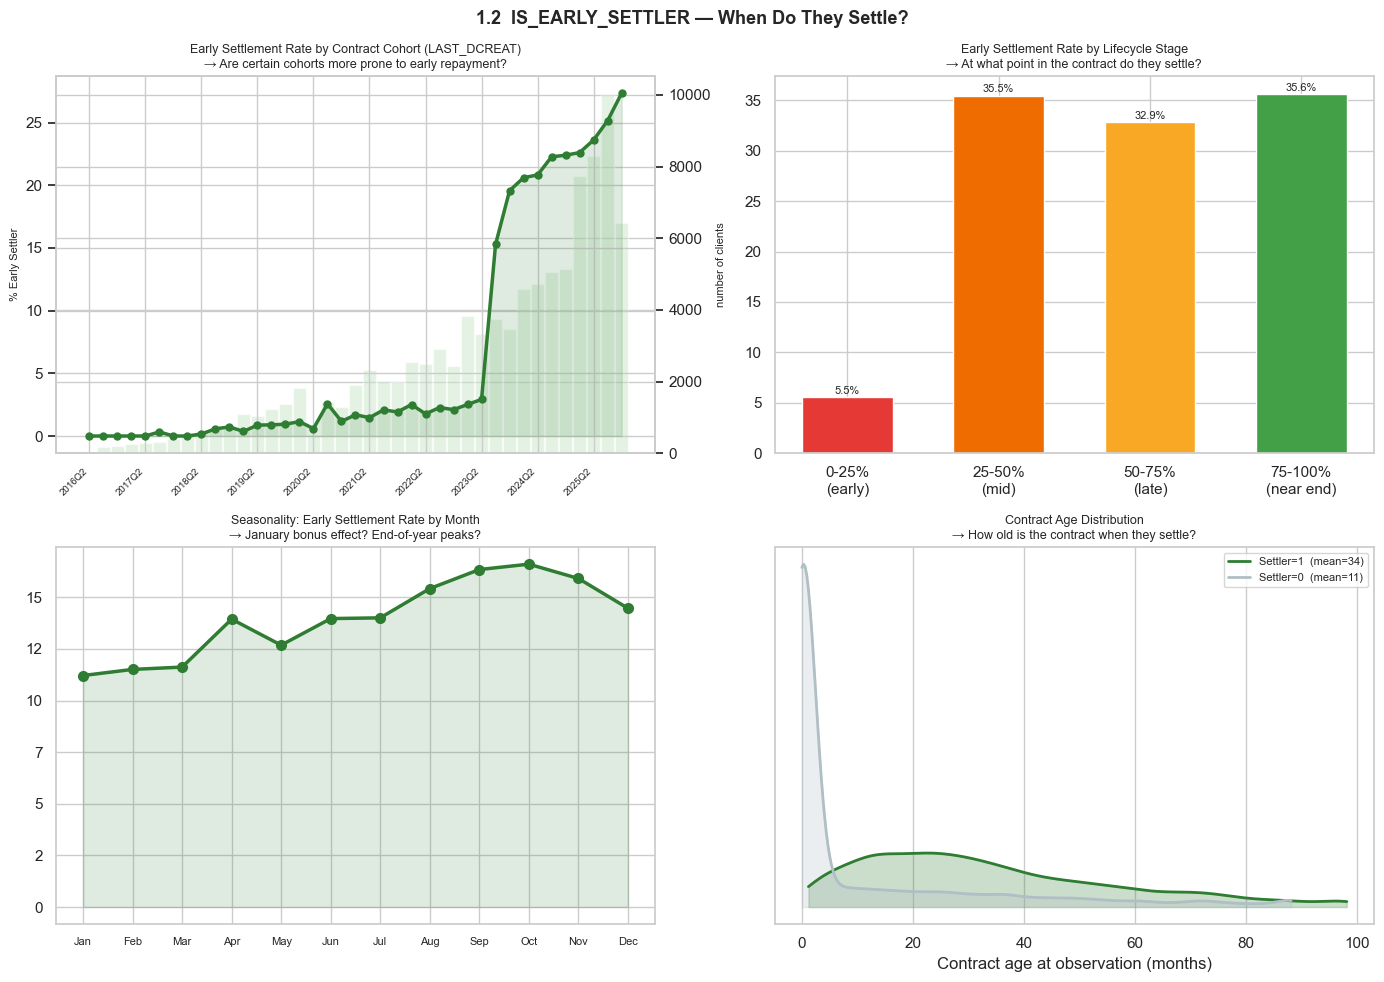

In [21]:
f.san_2_temporal(df2)

### Contract Cohort
The cohort chart now shows a clean upward trend from 2022 onwards,
with no distortion from old contracts. More recent cohorts show
progressively higher settlement rates, reaching ~27% in 2025Q2.
This may reflect a genuine trend of increasing early settlement
behaviour, or simply that more recent cohorts have had more time
to be observed as active clients.

### Lifecycle Stage
Unlike the full dataset where early settlement peaked at 25–75%,
here the 75–100% stage (35.6%) and 25–50% stage (35.5%) are
virtually equal, with 50–75% close behind (32.9%). Only the
earliest stage (0–25%) is clearly lower (5.5%). For active clients,
early settlement is distributed more evenly across the contract
lifecycle.

### Seasonality
The rate rises steadily from ~11% in January to a peak of ~17%
in October–November, then declines slightly in December. The
seasonal pattern is smoother and more pronounced than in the full
dataset, with a clear second-half-of-year tendency, consistent
with year-end bonus payments enabling early settlement.

### Contract Age
Early settlers (mean=34 months) are observed at older contract ages
than non-settlers (mean=11 months), consistent with the lifecycle
finding. The non-settler distribution is heavily concentrated near
zero, most active clients are still early in their contracts.

## 4.3 Financial Profile

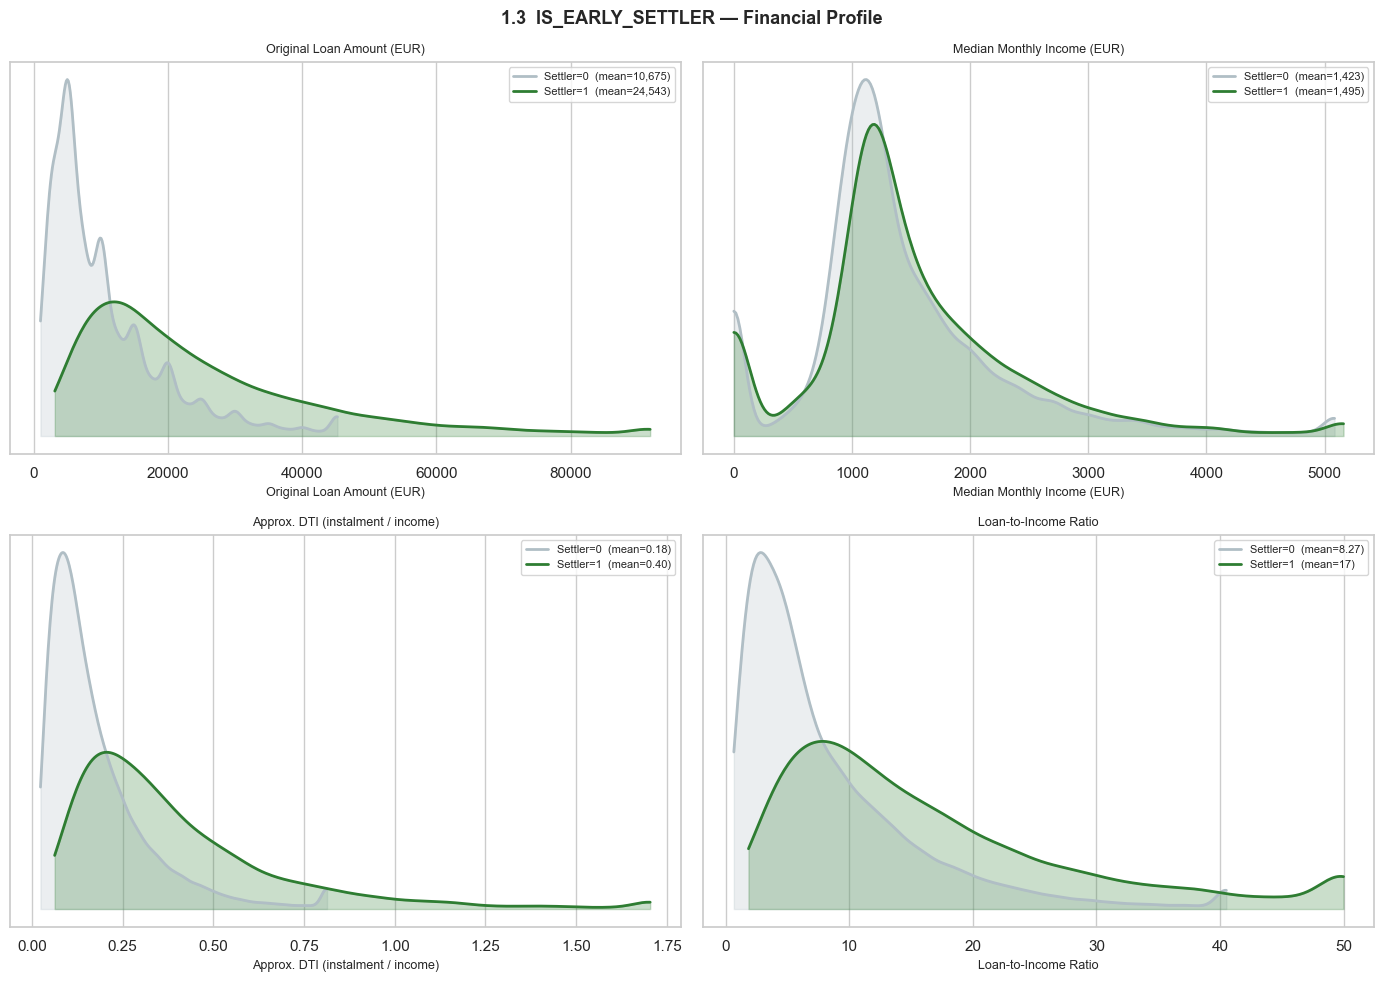

In [22]:
f.san_3_financial(df2)

### Original Loan Amount
The difference is now very pronounced: early settlers have a mean
loan of **€24,543 vs €10,675** for non-settlers, more than double.
The settler distribution is shifted clearly to the right. Loan
amount is one of the strongest discriminators in this active dataset.

### Median Monthly Income
Distributions overlap almost entirely (€1,495 vs €1,423). Income
alone remains a weak predictor.

### DTI
Early settlers now show a notably higher DTI (mean=0.40 vs 0.18), they commit a larger share of income to loan instalments, consistent
with having larger loans. This is a meaningful signal for the model.

### LTI
Early settlers have more than double the LTI (mean=17 vs 8.27),
confirming that they took out loans much larger relative to their
income. Combined with the DTI finding, this strongly suggests
that early settlement is driven by clients who took on larger
financial commitments and found the means to exit early.


## 4.4 Risk Profile

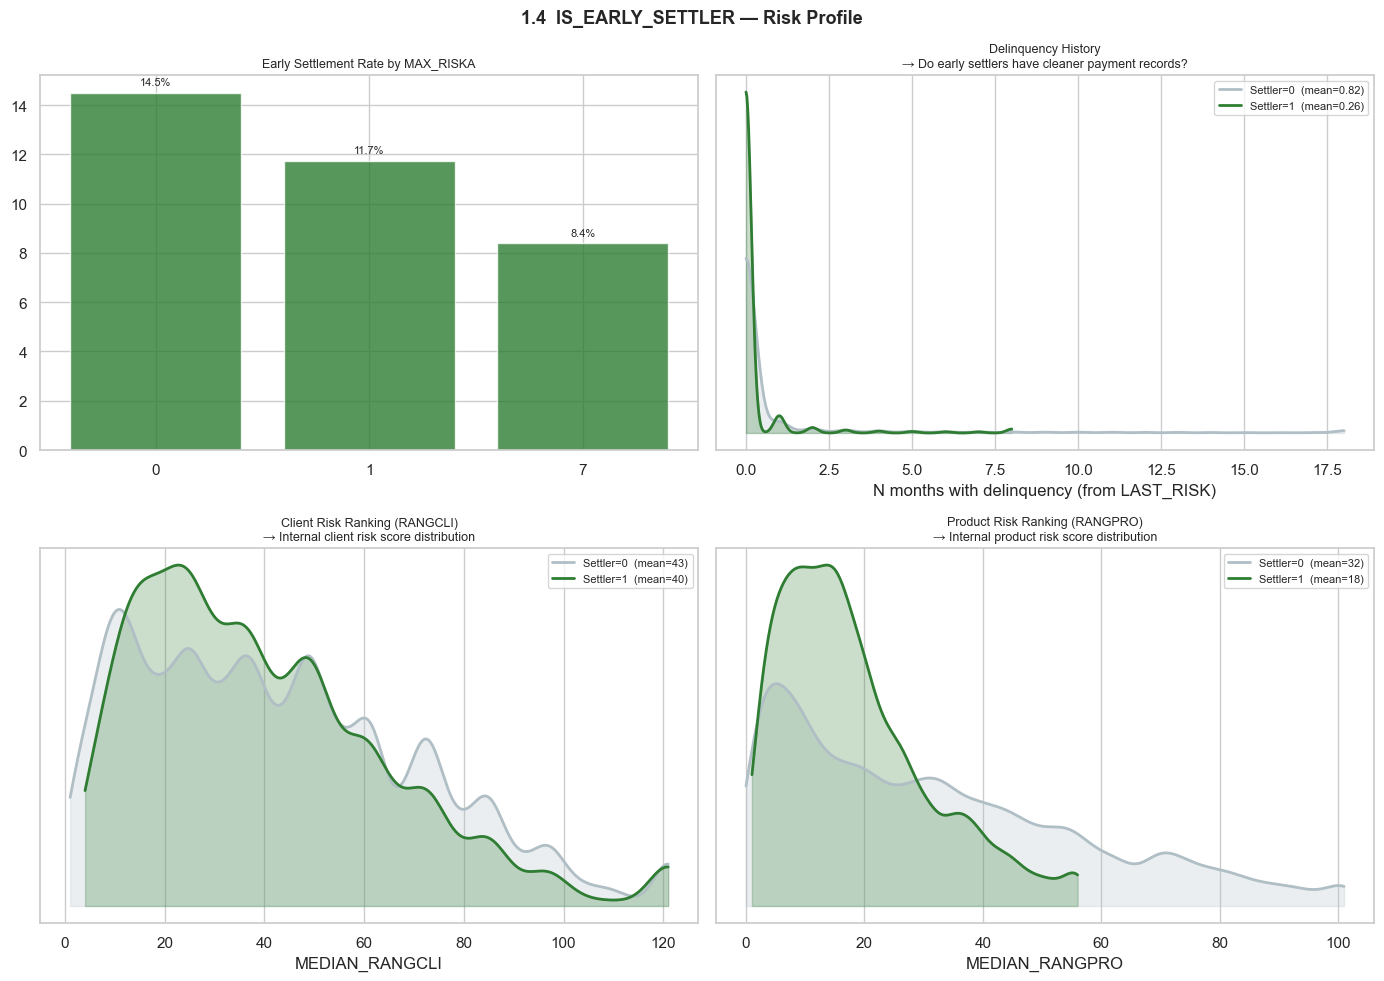

In [23]:
f.san_4_risk(df2)

### MAX_RISKA
The pattern is weaker than in the full dataset, rates are closer
together (14.5% vs 11.7% vs 8.4%). The direction is the same
(lower risk = more early settlement) but the signal is less pronounced.

### Delinquency History
Early settlers (mean=0.26 months) have significantly cleaner
payment records than non-settlers (mean=0.82 months). The settler
distribution is almost entirely at zero. Delinquency history
remains a useful signal even in the active client subset.

### RANGCLI
Early settlers (mean=40) have marginally lower client risk rankings
than non-settlers (mean=43). Distributions largely overlap.

### RANGPRO
The most discriminative chart: early settlers (mean=18) are
strongly concentrated at lower RANGPRO values compared to
non-settlers (mean=32). The settler distribution peaks sharply
near zero and drops off quickly, while non-settlers extend much
further right. RANGPRO remains the strongest risk-based predictor
of early settlement.

## 4.5 Demographics

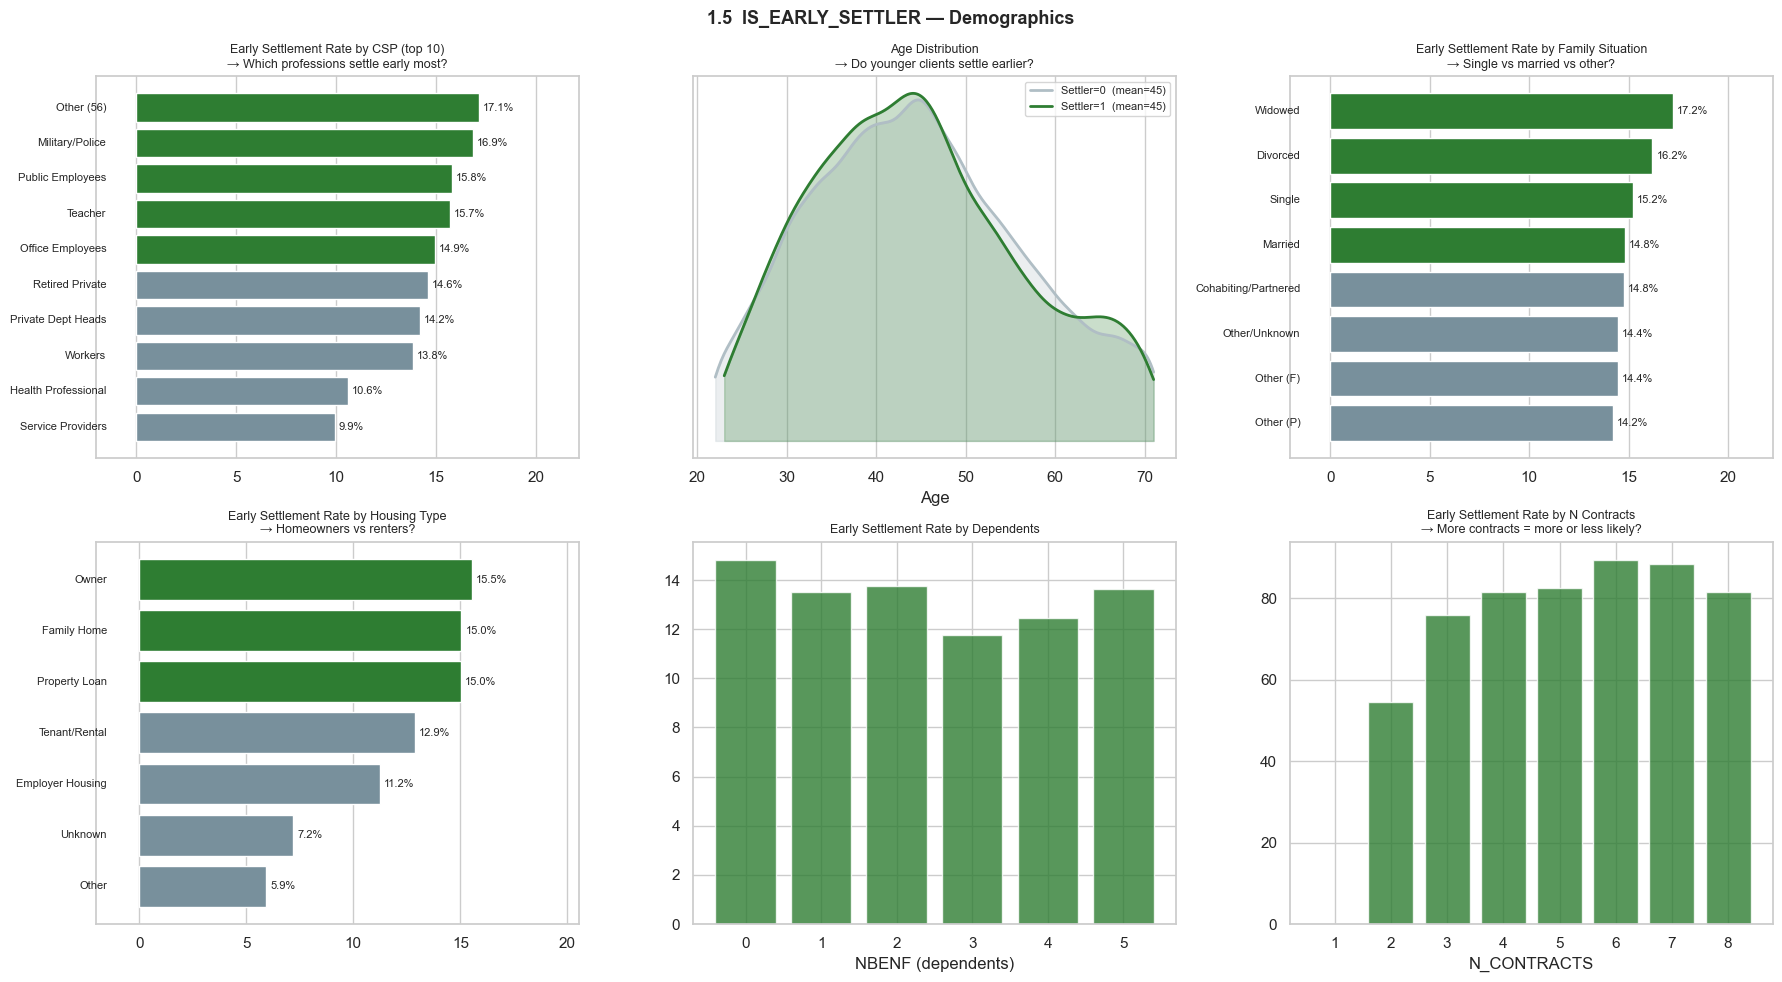

In [24]:
f.san_5_demographics(df2)

### CSP
The spread across professions is narrower (9.9%–17.1%) than in
the full dataset. Other (56) and Military/Police lead, while
Service Providers and Health Professionals have the lowest rates.
The profession signal is weaker for active clients.

### Age
Distributions are virtually identical (both mean=45). Age has
no discriminative power for early settlement in active clients.

### Family Situation
Widowed (17.2%) and Divorced (16.2%) clients settle early most
often, while the remaining categories cluster between 14–15%.
Differences are very small and unlikely to be actionable.

### Housing Type
Owner (15.5%), Family Home (15.0%), and Property Loan (15.0%)
are highest. The range is narrow (5.9%–15.5%), with Unknown
and Other at the low end likely reflecting data quality issues.

### Dependents
Flat across all values (~12–15%), with a slight peak at 0
dependents. Number of dependents is not a useful predictor.

### N_CONTRACTS
The same strong signal as before: clients with 1 contract have
~55% early settlement rate, rising sharply to ~75% for 2 contracts
and stabilising at 80–88% for 3+.

## 4.6 External Credit Exposure (CRC)

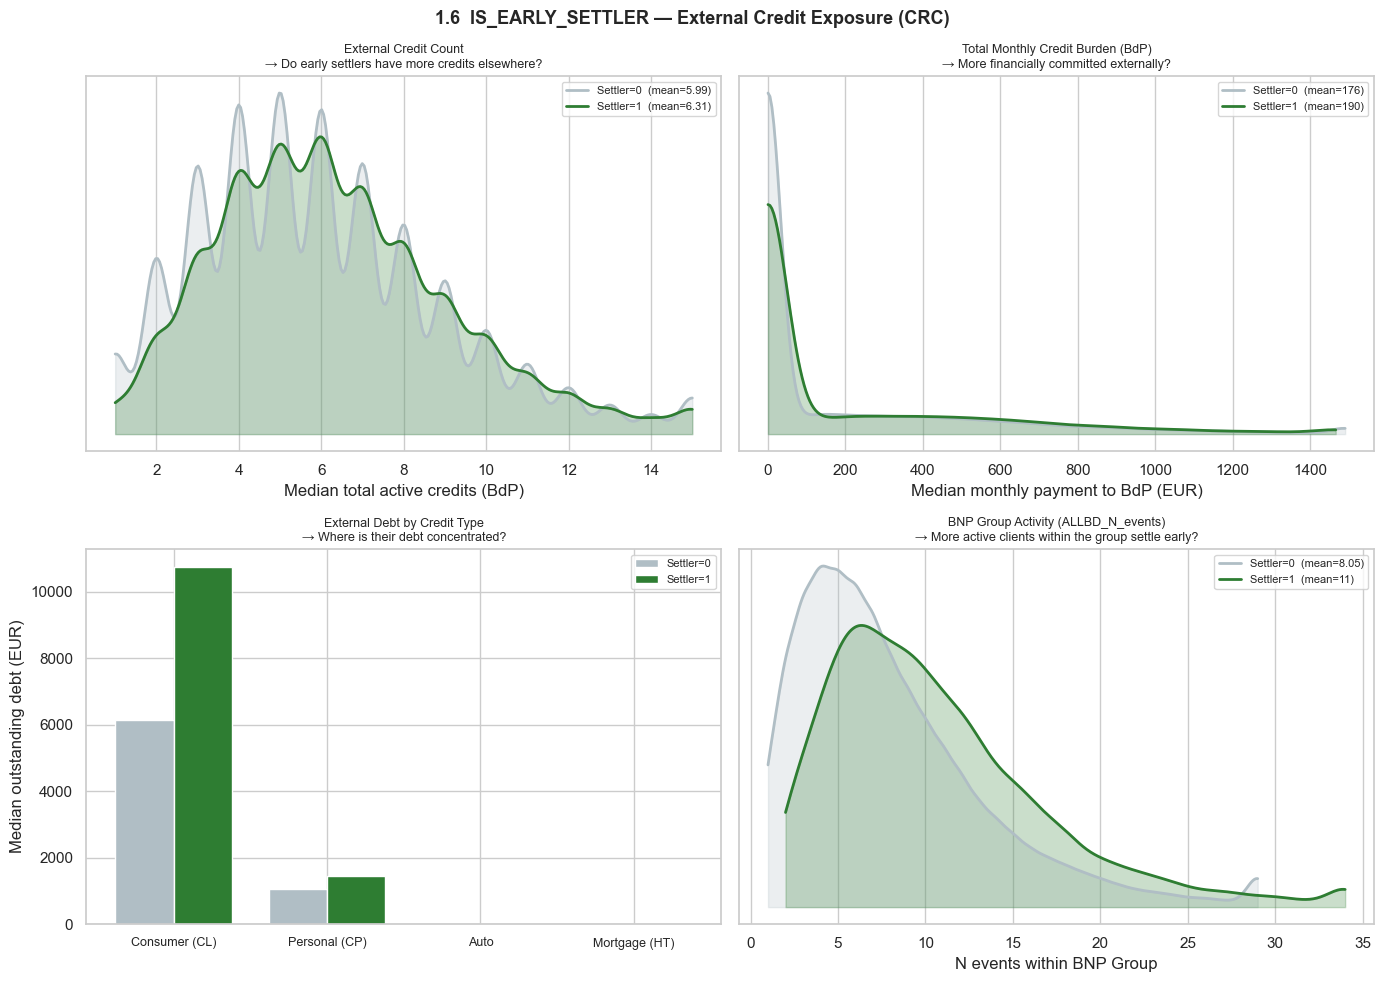

In [25]:
f.san_6_external(df2)

### External Credit Count
Early settlers (mean=6.31) have marginally more external credits
than non-settlers (mean=5.99). Distributions overlap completely.

### Monthly Credit Burden
Early settlers now pay **more** externally (mean=€190 vs €176),
the opposite of the full dataset finding. Combined with their
higher DTI, this confirms that active early settlers are clients
with high overall financial commitments who are actively managing
a large credit portfolio.

### External Debt by Credit Type
Consumer credit (CL) remains the dominant debt type, and the
gap is now larger: early settlers carry median €10,500 vs €6,100
for non-settlers. Personal credit (CP) shows a smaller difference
in the same direction. This reinforces the profile of financially
active clients with large consumer credit exposure.

### BNP Group Activity
Early settlers (mean=11) show more BNP group activity than
non-settlers (mean=8.05). The settler distribution is shifted
right. More engaged clients within the BNP group are more
likely to settle early.

## 4.7 Key Takeaways & Recommendations

### Who Are the Early Settlers?
Among active clients, early settlers represent **14.3%** of the 
portfolio — a minority but financially significant group. They are 
characterised by **much larger loans** (mean=€24,543 vs €10,675), 
**higher DTI** (0.40 vs 0.18), and **higher LTI** (17 vs 8.27). 
They are not financially distressed clients — they are high-commitment 
borrowers who took on larger obligations and found the means to exit 
early. 

### Risk Profile
Early settlers have cleaner payment records (mean=0.26 delinquency 
months vs 0.82) and lower RANGPRO scores, confirming that early 
settlement is a behaviour of low-risk, financially capable clients. 
MAX_RISKA is a weaker signal in the active dataset than in the full 
dataset.

### External Credit Behaviour
Active early settlers carry higher external financial commitments 
than non-settlers, more credits, higher monthly payments (€190 vs 
€176), and nearly double the consumer credit debt (€10,500 vs 
€6,100). This profile suggests clients who are actively consolidating 
or managing multiple credit products simultaneously, using Cetelem 
as one of several providers.

### Recommendations
Cetelem should focus retention efforts on clients with **large loan 
amounts, high DTI, low RANGPRO, as these combine 
the highest early settlement risk with the highest revenue impact. 
Proactive outreach from the **25% lifecycle mark** onwards, rather 
than waiting for the contract end, is key for this segment. 
Offering refinancing or top-up products before the settlement 
decision is made is the most direct lever to retain these 
high-value clients within the portfolio.